# Reproducing benchmark protocols of the literature

This is the worked companion to the [Benchmark](../benchmark/index.md) pages. It is organized across a few steps:

1. Protocol Calibration
2. Score predictions
3. Normalization of each scoring using what we refer to as SBB style normalization from {cite:t}`Vollenweider_2026`
4. Run pairwise statistical tests to robustly compare models

Additionally, the tutorial starts in [1.A,B](#a-reason-for-making-scperteval-fold-aware) by showing some patches to `scPertEval` that we decided to implement to show how it can be made fold aware. This is not strictly necessary but it is included for learning purposes, and it could also become a default in the future.

> [!TIP]
> The figures below are wide so click on one to open it at native resolution if the inline rendering is too small.

> [!WARNING]
> The conclusions in this tutorial must first be proof-checked against other datasets before being trusted as generalizations. It is therefore
> recommended to run the calibration step on every dataset.

First, we define the protocols being studied, as well as the prediction directory which is organized as follows:

```text
docs/
├── notebooks
│   └── 04_benchmark_implementation.ipynb
models/
├── baselines
│   └── <baseline model>
│       └── predictions
│           └── replogle22k562
│               └── fold_<i>.h5ad
├── data
│   └── replogle22k562
│       ├── kfold_splits.json
│       └── raw.h5ad
└── <deep-learning model>
    └── predictions
        └── replogle22k562
            └── fold_<i>.h5ad
```

In [ ]:
import warnings
from pathlib import Path

# Fold predictions reuse fold-local integer obs_names, so ad.concat()-ing them across folds
# (e.g. in _baseline_lookup below) always collides -- harmless, since only the "perturbation"
# column is read anywhere in this notebook, never obs_names itself.
warnings.filterwarnings("ignore", message="Observation names are not unique.*", category=UserWarning)
# pearson()'s np.corrcoef degenerates to 0/0 (NaN) when a centered vector is exactly constant --
# expected, not a bug, for the uninformative baselines against the metric family centered on their own reference
warnings.filterwarnings("ignore", message="invalid value encountered in divide", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)

PROTOCOL_SPECS = [
    # --- Ahlmann-Eltze et al. 2025 --- (their fixed 1000 control-highly-expressed-gene panel)
    "pearson_ctrl_heg_k=1000",  # headline "Pearson Delta"
    "l2_heg_k=1000",  # companion l2 metric
    # --- Miller et al. 2025: MSE (all genes / DEG / DE-weighted) ---
    "mse",
    "mse_degs_padj",
    "wmse_exp2",
    # --- Miller et al. 2025: PearsonDeltaCtrl ---
    "pearson_ctrl",
    "pearson_ctrl_degs_padj",
    "weighted_pearson_ctrl_exp2",  # Vollenweider & Bühlmann 2026's "Weighted Pearson Delta"
    # --- Miller et al. 2025: PearsonDeltaPerturbMean ---
    "pearson_pert",
    "pearson_pert_degs_padj",
    "weighted_pearson_pert_exp2",
    # --- Miller et al. 2025: R2DeltaCtrl ---
    "r2_ctrl",
    "r2_ctrl_degs_padj",
    "weighted_r2_ctrl_exp2",
    # --- Miller et al. 2025: R2DeltaPerturbMean ---
    "r2_pert",
    "r2_pert_degs_padj",
    "weighted_r2_pert_exp2",
    # --- Miller et al. 2025: Normalized Inverse Rank ---
    "nir",
]
HERE = Path.cwd().parent.parent / "models"  # run from docs/notebooks/ -- models/ is a repo-root sibling of docs/
DATASET_NAME = "replogle22k562"
RAW = HERE / "data" / DATASET_NAME / "raw.h5ad"

PREDICTION_DIRS = {
    "gears": HERE / "gears",
    "scgpt": HERE / "scgpt",
    "presage": HERE / "presage",
    "sclambda": HERE / "sclambda",
    "state": HERE / "state",
    "tabicl": HERE / "tabicl",
    "no_change": HERE / "baselines" / "no_change",
    "mean": HERE / "baselines" / "mean",
    "linear": HERE / "baselines" / "linear",
    # oracle upper bound, not a competing model on equal footing -- it has privileged access to a
    # real technical duplicate of the perturbation it predicts (see baselines.py's
    # interpolated_baseline). Scoreable the same way as every other prediction here regardless.
    "interpolated": HERE / "baselines" / "interpolated",
}

## 1. Protocol Calibration

### A. Reason for making scPertEval fold aware
<!-- collapse-section: Click to expand -->

#### i. The default positive and negative baselines in Calibration

In [Tutorial 3: Python API](03_python_api.ipynb), you learned how to calibrate protocols, notably with the $\mathrm{DRF}$ and the $\mathrm{BDS}$. In our setting, every protocol compares perturbations using a centroid representation (which means that for a given perturbation, its samples are averaged). Therefore:

For a perturbation $a$, let its average over two halves of its population $a^{(1)},a^{(2)}$ be $\bar{X}_{a^{(1)}}$ and $\bar{X}_{a^{(2)}}$:

$$
\operatorname{DRF}(a)
= \frac{s_{\text{neg}}^{(a)} - s_{\text{pos}}^{(a)}}{s_{\text{neg}}^{(a)} - s_{\text{optim}} + \xi}
;\quad 
\operatorname{BDS}
= \frac{1}{|\mathcal{P}|}
  \sum_{a \in \mathcal{P}}
  \mathbf{1}\!\left[s_{\text{pos}}^{(a)} < s_{\text{neg}}^{(a)}\right]
$$

Where $s_{\text{pos}}^{(a)}$ is the score of a positive baseline $\bar{X}^\mathrm{pos}_{a}$ against the ground truth. Naming $d(\cdot, \cdot)$ a certain metric function being calibrated, then: $s_{\text{pos}}^{(a)} = d(\bar{X}^\mathrm{pos}_{a}, \bar{X}_{a^{(1)}})$. Similarly $s_{\text{neg}}^{(a)}$ is defined for a negative baseline $\bar{X}^\mathrm{neg}_{a}$ as: $s_{\text{neg}}^{(a)} = d(\bar{X}^\mathrm{neg}_{a}, \bar{X}_{a^{(1)}})$

It is worth noting that `scPertEval` internals uses the following defaults, following {cite:t}`Miller_2025`:

- `default_negative`: `all_perturbed_mean`, the centroid average across every perturbation except for the given perturbation $a$.

  $$
  \bar\mu_g^{-a} = \frac{1}{|\mathcal A|-1}\sum_{b\in\mathcal A\setminus\{a\}} \bar X_g(b)
  $$

- `default_positive`: `interpolated`, the interpolation between the `all_perturbed_mean` baseline and the ground truth (the technical duplicate $\bar{X}_{a^{(2)}}$):

  Defined for a given perturbation $a$ and a gene $g$ as:

  $$
  \mathrm{interp}_g(a) = \alpha_g(a)\bar{X}_{a^{(2)}} + \big(1-\alpha_g(a)\big)\bar{\mu}_g^{-a}
  $$

  where $\alpha_g(a) = 1-\mathrm{padj}_g\big(a^{(2)} \text{ vs all-perturbed}^{-a}\big)$.

  The coefficients $\alpha$ are computed using the adjusted p-value derived from testing for differentially expressed genes between the perturbation $a$ and every other perturbation except for $a$.

Alternatively for metrics which are centered on the `all_perturbed_mean`, the default negative becomes `control`, the raw control cells, pooled to a centroid at call time, since the `all_perturbed_mean` baseline would otherwise be ~0 after centering.

The only specific protocol in our setting is the rank-based metric $\mathrm{NIR}$ (the normalized inverse rank). It is the only protocol which uses the `scope=dataset`, which means that every perturbation is scored at once. For a given perturbation $a$, it ranks the $\mathrm{MSE}$ between the predicted outcome of the perturbation $a$, $\hat{\bar{X}}_a$ against its ground truth $\bar{X}_{a^{(1)}}$ vs every other $\mathrm{MSE}$ of the $\hat{\bar{X}}_a$ and any perturbation ground truth $\bar{X}_{b^{(1)}}$:

$$
\mathrm{NIR}(a) = 1-\frac{1}{|\mathcal{A}|-1}\mathrm{rank}_{b\in\mathcal{A}}\big(\|\hat{\bar{X}}_a-\bar{X}_{b^{(1)}}\|^2\big)\Big|_{b=a}
$$

In the context of $\mathrm{NIR}$, the `default_negative` is the `global_mean`, which is the `all_perturbed_mean` but also includes perturbation $a$ itself, since the baseline needs to be the same across the dataset, as it is a `dataset`-scope metric.

> [!IMPORTANT]
> Overall, for a given *tested* perturbation $a$, the `interpolated` and `all_perturbed_mean` baselines depend on every perturbation present in the dataset. Similarly, $\mathrm{DEG}$-based or weighted metrics compute their statistic by comparing the *tested* perturbation $a$ to every other perturbation in the dataset.
> Rank-based metrics rank the perturbation $a$ against every perturbation in the dataset.

#### ii. Why is it problematic to have an evaluation protocol fold-agnostic?

Strictly speaking, this isn't data leakage in the sense of giving a model illegitimate access to test labels -- the models are already trained and frozen before any of this runs, and there is nothing methodologically *wrong* with computing these quantities dataset-wide. For instance, {cite:t}`Vollenweider_2026` make exactly this choice for their $\mathrm{DEG}$ weights and defend it explicitly: *"we compute $\mathrm{DEG}$ weights across the entire dataset (both training and testing partitions), rather than exclusively from the training set. Since these weights serve only for evaluation, this yields a test-set-dependent metric that we consider appropriate"* (reporting train-set-only weights separately, as a robustness check).

We choose differently, for a reason specific to what these quantities are *for*: a model is *trained on one partition* and *deployed against an independent* one it never anticipated. 

A metric meant to say something about that deployment setting should only use **what's available at the point the model is trained and shipped** -- the train partition -- not a **test set that, in a real deployment, wouldn't exist yet** and could have looked arbitrarily different. Concretely:

- $\mathrm{DRF}$ asks how much of the room between ground truth and the negative baseline the interpolated duplicate already fills -- a property of the perturbation and its training data, not of which other perturbations happened to land in the test set.
- $\mathrm{NIR}$ asks whether a prediction can be told apart from other true perturbation effects. Which, or how many, other perturbations end up in the test set is arbitrary; what matters is whether the prediction is distinguishable from what the model actually trained on.
- $\mathrm{DEG}$/weighted-metric gene rankings say which genes matter for a perturbation -- a judgment that shouldn't depend on test-set profiles a practitioner ranking genes for evaluation, before any results come in, would never have.

So this is a genuine, defensible choice either way, not a bug we're fixing -- we simply think the train-restricted version asks the more relevant question for evaluating models meant to generalize. This is a tutorial, so treat it as our default rather than a requirement: if you'd rather keep `scPertEval`'s dataset-wide convention, skip the patching cells below in [section 1.B](#b-scperteval-patch-to-make-it-fold-aware) and every built-in will resolve exactly as documented.

### B. scPertEval patch to make it fold aware
<!-- collapse-section: Click to expand -->

We therefore restrict every previous definition to the respective train set of the perturbation $a$, $\mathrm{Train}(a)$:

- `all_perturbed_mean`
  
  $$
  \bar\mu_g^{\mathrm{Train}(a)} = \frac{1}{|\mathrm{Train}(a)|}\sum_{b\in \mathrm{Train}(a)} \bar X_g(b)
  $$

- The DEG `t-test` statistic:
  
  $$
  s_g^{\mathrm{Train}}(a) = t\text{-test}\big(X_g(a^{(1)}),\, X_g(\mathrm{Train}(a))\big)
  $$

- `interpolated`
  
  $$
  \mathrm{interp}_g^{\mathrm{Train}}(a) = \alpha_g^{\mathrm{Train}}(a)\,\bar X_g(a^{(2)}) + \big(1-\alpha_g^{\mathrm{Train}}(a)\big)\,\bar\mu_g^{\mathrm{Train}(a)}
  $$

  with $\alpha_g^{\mathrm{Train}}(a) = 1-\mathrm{padj}_g\big(a^{(2)} \text{ vs } \mathrm{Train}(a)\big)$.

- `NIR`:
  
  $$
  \mathrm{NIR}^{\mathrm{Train}}(a) = 1-\frac{1}{|\mathrm{Train}(a)|}\,\mathrm{rank}_{b\in \mathrm{Train}(a)\cup\{a\}}\big(\|\hat X(a)-X(b)\|^2\big)\Big|_{b=a}
  $$


Interpolated duplicate / all-perturbed mean are precomputed this way in `scPertEval-models` and registered below under scPertEval's own names; the $\mathrm{DEG}$/weighted-metric DE statistic and $\mathrm{NIR}$ are patched directly (no per-call override exists for either in the public API).

One more distinction, orthogonal to fold-restriction: $\mathrm{DRF}$'s positive control above is Miller et al. 2025's DE-weighted *interpolated* duplicate -- a shrinkage blend toward the negative baseline for weak-effect perturbations. $\mathrm{BDS}$ and the SBB-calibrated score (further below) use a different, unblended positive baseline instead -- the raw held-out replicate itself -- since that's how {cite:t}`Vollenweider_2026` define it; see the [SBB Normalization](#3-sbb-normalization) section below for why the interpolated version isn't a drop-in substitute there.

#### i. SOURCES

In [2]:
import anndata as ad
import numpy as np

from scperteval.sources import SOURCES
from scperteval.dataset import to_dense


def _baseline_lookup(name: str, n_folds: int = 5) -> dict[str, np.ndarray]:
    """{perturbation: predicted row}, concatenated across a baseline's per-fold predictions."""
    concatenated = ad.concat(
        [ad.read_h5ad(PREDICTION_DIRS[name] / "predictions" / DATASET_NAME / f"fold_{i}.h5ad") for i in range(n_folds)]
    )
    return dict(zip(concatenated.obs["perturbation"], concatenated.X, strict=True))  # type: ignore


# Registered under scPertEval's own names -- centering="all_perturbed_mean" is baked into
# pearson_pert/r2_pert/... with no per-call override, so only overriding the built-in name reaches
# it. "global_mean" gets the same fold_negative lookup as "all_perturbed_mean": both collapse to
# "this fold's train mean" once restricted to Train(p).
#
# Global, process-wide override, resolved once at import -- re-run after any %autoreload-triggered
# reload of scperteval.sources.
fold_negative = _baseline_lookup("mean")
fold_positive = _baseline_lookup("interpolated")
SOURCES.register("all_perturbed_mean", provides="centroid", description="fold-restricted negative control (override)")(
    lambda ctx, pert: fold_negative[pert]
)
SOURCES.register("global_mean", provides="centroid", description="fold-restricted chance-level baseline (override)")(
    lambda ctx, pert: fold_negative[pert]
)
SOURCES.register("interpolated", provides="centroid", description="fold-restricted positive control (override)")(
    lambda ctx, pert: fold_positive[pert]
)

# BDS/SBB's positive baseline is the raw technical duplicate, not DRF's interpolated one (see the
# markdown above) -- scPertEval only wires "interpolated" in as the default centroid positive, so
# without this override DRF and BDS would silently share it. Reuses the exact half src_interpolated
# blends internally (`ctx.ds.cells(..., half="second")`), not a re-derivation; no fold restriction
# needed since it only touches this perturbation's own held-out cells.
SOURCES.register(
    "tech_dup_mean", provides="centroid", description="raw technical-duplicate centroid, unblended (BDS/SBB positive)"
)(lambda ctx, pert: np.asarray(to_dense(ctx.ds.cells(pert, half="second"))).mean(0));

#### ii. DEG-space / weighted metric

In [3]:
import json

from scperteval.blocks.de import _moments as _de_moments
from scperteval.context import Context

kfold_splits = json.loads((HERE / "data" / DATASET_NAME / "kfold_splits.json").read_text())
pert_to_fold = {pert: i for i, fold in enumerate(kfold_splits) for pert in fold["test"]}

# "all_perturbed" is hardcoded in Context._moments/_de_cells (bypasses the SOURCES registry), so
# the override above can't reach the DEG-space/weighted-metric DE call
# (ctx.de(pert, cfg.truth, "all_perturbed")). Pooled cells from this perturbation's own fold's
# train set, same convention as baselines.py's interpolated_baseline; computed once per fold since
# it never varies within one. Loaded independently from raw.h5ad, reusing scPertEval's own
# `_moments` formula rather than a third re-derivation of it.
_raw = ad.read_h5ad(RAW)
_pert_labels = _raw.obs["perturbation"].to_numpy()
fold_de_moments = {i: _de_moments(_raw.X[np.isin(_pert_labels, fold["train"])]) for i, fold in enumerate(kfold_splits)}  # type: ignore
del _raw, _pert_labels

# Patches Context._moments specifically: it's the only DE entry point de_method="t-test" exercises
# (declares a from_moments capability, see blocks/de.py) -- a de_method without that capability
# (e.g. "MWU") would also need _de_cells patched, which this does not do.
_orig_moments = Context._moments


def _fold_moments(self, source, pert):
    if source == "all_perturbed":
        return fold_de_moments[pert_to_fold[pert]]
    return _orig_moments(self, source, pert)


Context._moments = _fold_moments

#### iii. Normalized Inverse Rank

In [4]:
from scperteval.protocols import metrics as M
from scperteval.protocols.metrics import _sq_dists

_orig_rank_retrieval = M.rank_retrieval
_fold_train_sets = [set(fold["train"]) for fold in kfold_splits]


def _fold_rank_retrieval(gt, prediction, ctx, transpose=False):
    """Same as the original, but each perturbation's rank is computed only against its own fold's TRAIN pert.

    A perturbation is never a member of its own fold's train set (train/test are disjoint), so
    its own ground truth -- the one correct answer -- is force-included in its column's pool;
    everything else in that column is exactly its fold's train perturbations.
    """
    G = np.vstack(gt)
    P = np.vstack(prediction)
    sq = _sq_dists(P, G)
    if transpose:
        sq = sq.T
    noise = np.random.default_rng(42).uniform(0, 1e-12, size=sq.shape)
    sq = sq + noise

    perts = list(ctx.perturbations)
    n = len(perts)
    eligible = np.zeros((n, n), dtype=bool)
    for b, pb in enumerate(perts):
        train_set = _fold_train_sets[pert_to_fold[pb]]
        eligible[:, b] = [pa in train_set for pa in perts]
        eligible[b, b] = True  # pb's own ground truth: the correct answer, not a competitor
    sq = np.where(eligible, sq, np.inf)

    ranks = np.argsort(np.argsort(sq, axis=0), axis=0)
    pool_size = eligible.sum(axis=0)  # per-column: this fold's train-set size + 1 (the diagonal)
    return np.diag(ranks).astype(np.float64) / np.maximum(pool_size - 1, 1)


M.rank_retrieval = _fold_rank_retrieval
# Only reaches protocols that look up "rank_retrieval" by name at call time -- true for `nir`, but
# NOT "rank"/"transpose_rank": their Protocol rows hold partial(M.rank_retrieval, ...), capturing
# the original function object at table.py's import time.

### C. Calibration loop

In [5]:
import pandas as pd
from tqdm import tqdm

import scperteval as sp
from scperteval.protocols.resolve import resolve_protocols

protocols = resolve_protocols(PROTOCOL_SPECS)
prepared = sp.prepare(str(RAW), protocols=[p.name for p in protocols])

rows = []
per_pert_calib_rows = []
native_bounds = {}
interpolated_scores = {}
for p in tqdm(protocols, desc="calibrating", ncols=80):
    # "auto" resolves through the fold-restricted overrides above; pearson_pert/r2_pert's own
    # "control" negative is untouched (fold-independent by design), so no special-casing needed.
    drf_result = sp.calibrate(prepared, p.name, calibrator="drf")
    rows.append({"protocol": p.name, "calibrator": "drf", **drf_result.aggregate})

    # BDS uses the raw technical duplicate (see markdown above), not DRF's interpolated one.
    bds_result = sp.calibrate(prepared, p.name, calibrator="bds", positive="tech_dup_mean")
    rows.append({"protocol": p.name, "calibrator": "bds", **bds_result.aggregate})

    pp_drf = drf_result.per_perturbation
    pp_bds = bds_result.per_perturbation
    bds_by_pert = dict(zip(pp_bds["perturbation"], pp_bds["bds"], strict=True))

    # Native (positive, negative) bounds per perturbation, from the BDS call -- reused by the
    # SBB-calibrated score below so it calibrates against the same raw-duplicate bound.
    native_bounds[p.name] = {
        pert: {"positive": pos, "negative": neg}
        for pert, pos, neg in zip(pp_bds["perturbation"], pp_bds["raw_positive"], pp_bds["raw_negative"], strict=True)
    }

    # DRF's own positive control IS interpolated, scored against gt_half -- reuse it directly as
    # `interpolated`'s "prediction" score below instead of re-running sp.score(): indeed sp.score score against the full population
    # which is unfair for interpolated duplicate as it is being constructed from the second halves of ground truth.
    interpolated_scores[p.name] = dict(zip(pp_drf["perturbation"], pp_drf["raw_positive"], strict=True))

    # Per-perturbation drf/bds, tagged by fold -- lets the plots show per-perturbation spread
    # alongside each fold's own aggregate, instead of one pooled number per protocol.
    for pert, drf_val in zip(pp_drf["perturbation"], pp_drf["drf"], strict=True):
        fold = pert_to_fold[pert]
        per_pert_calib_rows.append(
            {"protocol": p.name, "calibrator": "drf", "perturbation": pert, "fold": fold, "value": drf_val}
        )
        per_pert_calib_rows.append(
            {"protocol": p.name, "calibrator": "bds", "perturbation": pert, "fold": fold, "value": bds_by_pert[pert]}
        )

calib = pd.DataFrame(rows)
per_pert_calib = pd.DataFrame(per_pert_calib_rows)

# Shared row order for every model-comparison figure below (calibration overview, SBB heatmap,
# stripplot, significance cliques) -- DRF median, ascending -- so a protocol sits in the same
# position everywhere instead of each figure sorting/grouping independently.
protocol_order = (
    per_pert_calib[per_pert_calib["calibrator"] == "drf"]
    .dropna(subset=["value"])
    .groupby("protocol")["value"]
    .median()
    .sort_values()
    .index
)

calibrating: 100%|██████████████████████████████| 18/18 [00:47<00:00,  2.64s/it]


### D. Effective gene count

Additionally, we investigate the number of genes or dimensions each protocol is effectively being evaluated onto. 

For most protocols, the answer is straightforward: 
- For those evaluated on the _Differentially Expressed Genes Space_ with an adjusted $p_\mathrm{value} < 0.05$, it suffice to control for genes actually passing the threshold.
- For the _Full Space_, this is the total amount of genes.
- For the _Highly Expressed Genes Space_ with a fixed gene count, this is simply that fixed amount.

However, for any _weighted metrics_ evaluated on the full space, we can compute an effective gene count as follows:

For perturbation $a$ and gene $g$, with $s_{g,a}$ the DE test statistic (t-test) and $\exp$ the metric's own weighting exponent, the weight and effective gene count are:

$$
w_{g,a} = \mathrm{Mejia}_{weight}\left(\left(s_{g,a}\right)_{g\in\mathcal{G}}, \exp\right) 
;\quad N_a^{\text{eff}} = \frac{\sum_g w_{g,a}}{\max_g w_{g,a}}
$$

Where the $\mathrm{Mejia}_{weight}$ from {cite:t}`Mejia_2025` is simply a $\mathrm{min-max}$ scaling of the statistics and a normalization so that it sums to 1:

$$
\bar{s}_{g,a} = \left(\frac{|s_{g,a}| - \min_g |s_{g,a}|}{\max_g |s_{g,a}| - \min_g |s_{g,a}|}\right)^{\exp}; \quad w_{g,a} = \frac{\bar{s}_{g,a}}{\sum_g \bar{s}_{g,a}}
$$

In [6]:
from functools import partial

import pandas as pd

from scperteval.blocks.de import mejia_weights

de = sp.de(prepared, method="t-test")
perts = list(de.statistic.index)

rows = []
for p in protocols:
    if isinstance(p.metric, partial) and "exp" in p.metric.keywords:
        exp = p.metric.keywords["exp"]
        for pert in perts:
            w = mejia_weights(de.statistic.loc[pert].to_numpy(), exp)
            if w.max() > 0:
                rows.append(
                    {
                        "protocol": p.name,
                        "kind": "weighted (effective)",
                        "perturbation": pert,
                        "count": float(w.sum() / w.max()),
                    }
                )
    elif p.space.startswith("degs_"):
        padj = float(p.space.split("_", 1)[1])
        for pert in perts:
            count = float(np.sum(de.pvalue_adj.loc[pert].to_numpy() < padj))
            rows.append({"protocol": p.name, "kind": "DEGs (padj threshold)", "perturbation": pert, "count": count})
    elif p.space == "full":
        count = float(de.statistic.shape[1])
        rows += [{"protocol": p.name, "kind": "all genes", "perturbation": pert, "count": count} for pert in perts]
    else:  # heg_<k> / top_<k> fixed-size spaces
        count = float(p.space.split("_")[-1])
        rows += [{"protocol": p.name, "kind": "fixed top-k", "perturbation": pert, "count": count} for pert in perts]

gene_counts = pd.DataFrame(rows)

### E. Results

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# "retina" renders at 2x pixel density so the notebook viewer can scale the image down to its
# column width without looking soft on a high-DPI display. dpi=60 (-> 120 effective, doubled by
# retina) is sized for this docs site's own column width (sphinx-book-theme, ~800-900px)
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.dpi"] = 60


def _drf_panel(ax, drf_df, order, title):
    """Boxplot of per-perturbation DRF, fold means as diamonds, pooled mean as a dotted tick."""
    fold_means = drf_df.groupby(["protocol", "fold"], as_index=False)["value"].mean()
    pooled_mean = drf_df.groupby("protocol")["value"].mean().reindex(order)
    sns.boxplot(data=drf_df, y="protocol", x="value", order=order, color="#a8c8ec", fliersize=2, linewidth=0.8, ax=ax)
    sns.stripplot(
        data=fold_means, y="protocol", x="value", order=order, color="#0b0b0b", marker="D", size=5, jitter=False, ax=ax
    )
    for i, val in enumerate(pooled_mean.to_numpy()):
        if np.isfinite(val):
            ax.vlines(val, i - 0.4, i + 0.4, color="#c0392b", linestyle=":", linewidth=1.8, zorder=6)
    ax.set_xlabel("Dynamic Range Fraction")
    ax.set_title(title, fontsize=10, fontweight="bold")


def _gene_count_panel(ax, gc_df, order, title):
    """Median dot + IQR whisker (violin for variable-count kinds), mean tick, n=/n_eff= labels."""
    fixed_mask = gc_df["kind"].isin(["all genes", "fixed top-k"])
    # Violin for the two "variable" kinds -- 1771 perturbations per protocol makes a beeswarm
    # impractical (either unreadably dense or too slow to lay out without overlap), but plenty
    # for a KDE to show real shape (skew, multimodality) that a median+IQR whisker alone hides.
    sns.violinplot(
        data=gc_df[~fixed_mask],
        y="protocol",
        x="count",
        order=order,
        color="#f6cf83",
        inner="quartile",
        inner_kws={"linewidth": 0.8, "color": "#8a6d00"},
        cut=0,
        linewidth=0.8,
        log_scale=True,
        ax=ax,
    )
    # Fixed-count kinds have zero per-perturbation variance -- a violin there is a degenerate
    # spike, so they keep the median dot instead (a "fixed" protocol's repeated-constant rows
    # still collapse to a zero-width whisker on their own if ever mixed back in).
    sns.pointplot(
        data=gc_df[fixed_mask],
        y="protocol",
        x="count",
        order=order,
        estimator="median",
        errorbar=("pi", 50),
        color="#eda100",
        linestyle="none",
        markersize=5,
        ax=ax,
    )
    # text labels only -- the median dot and whisker above are already seaborn's own computation
    # from the raw per-perturbation counts, this just adds the n=/n_eff= semantic annotation.
    stat = gc_df.groupby("protocol")["count"].agg(mean="mean", median="median", max="max").reindex(order)
    kind = gc_df.drop_duplicates("protocol").set_index("protocol")["kind"].reindex(order)
    is_weighted = (kind == "weighted (effective)").to_numpy()
    variable = kind.isin(["DEGs (padj threshold)", "weighted (effective)"]).to_numpy()
    prefix = np.where(is_weighted, r"$n_{\mathrm{eff}}$", "n")
    mark = np.where(variable, "≈", "=")
    # Variable rows place the label past the violin's own tip (its max, since cut=0 keeps the
    # violin from extending beyond the data) rather than at p75, which would sit inside the
    # violin body and overlap it. Fixed rows have no violin, so their own value works as before.
    label_x = np.where(variable, stat["max"].to_numpy(), stat["median"].to_numpy())
    labels = zip(prefix, mark, label_x, stat["mean"].to_numpy(), stat["median"].to_numpy(), variable, strict=True)
    for i, (pre, m, x, avg, med, var) in enumerate(labels):
        if not np.isfinite(x):
            continue  # protocol has no rows in this (possibly filtered) subset -- nothing to label
        text = f"{pre}{m}{round(avg)} (md {round(med)})" if var else f"{pre}{m}{round(avg)}"
        ax.text(x * 1.15, i, text, va="center", fontsize=7, color="#0b0b0b")
    gene_mean = gc_df.groupby("protocol")["count"].mean().reindex(order)
    ax.plot(
        gene_mean.to_numpy(),
        np.arange(len(order)),
        linestyle="none",
        marker="+",
        markersize=8,
        markeredgewidth=1.5,
        color="#6b6a63",
        zorder=6,
    )
    ax.set_xscale("log")
    finite_max = label_x[np.isfinite(label_x)]
    xmax = finite_max.max() if len(finite_max) else gc_df["count"].max()
    ax.set_xlim(gene_counts["count"].min() * 0.7, xmax * 3.0)
    ax.set_xlabel("genes the score is computed over (log)")
    ax.set_title(title, fontsize=10, fontweight="bold")


def plot_calibration_overview(
    per_pert_calib: pd.DataFrame, gene_counts: pd.DataFrame, bds_filter: bool = False
) -> None:
    """DRF, BDS, and gene count per protocol, as horizontal panels on one shared protocol axis.

    - DRF panel: boxplot of the full per-perturbation distribution (every fold pooled), with
      each fold's own mean overlaid as a diamond, and the single pooled mean (every fold,
      every perturbation) overlaid as a dotted vertical tick -- since `protocol_order` sorts by
      the pooled *median*, this tick is the one place a protocol's mean-vs-median gap (e.g. a
      long tail from a handful of near-degenerate perturbations) becomes visible without
      re-deriving it from the fold diamonds.
    - BDS panel: bar for the pooled win-fraction (a 0/1 per-perturbation quantity has no
      distribution shape worth boxing), with each fold's own win-fraction overlaid the same way.
      No separate pooled-mean marker here -- a win-fraction bar already *is* a mean.
    - Gene-count panel: median dot + 25th-75th percentile whisker, computed by seaborn directly
      from `gene_counts`' raw per-perturbation counts (a "fixed" protocol's repeated-constant
      rows collapse to a zero-width whisker on their own, no separate branch needed for that),
      plus a lightweight "+" tick for the mean -- most informative for DEG-restricted/n_eff rows,
      where the per-perturbation gene count actually varies and a mean/median gap flags skew.

    With ``bds_filter=True``, BDS drops out (a 0/1 quantity has nothing left to show once every
    row is 1 by construction) and DRF/gene count are instead restricted to the perturbations
    where that protocol's own BDS check passes -- the subpopulation its BDS score claims it can
    discriminate on. Each row's label grows a ``(n=passing/total)`` suffix, since the passing
    fraction varies a lot by protocol (e.g. a low-BDS protocol keeps very few perturbations here),
    following the same row-label pattern as `plot_sbb_heatmap`'s own BDS annotation.
    """
    order = protocol_order  # shared across every model-comparison figure in this notebook
    drf = per_pert_calib[per_pert_calib["calibrator"] == "drf"].dropna(subset=["value"])
    bds = per_pert_calib[per_pert_calib["calibrator"] == "bds"].dropna(subset=["value"])

    if bds_filter:
        bds_pass = bds.loc[bds["value"] == 1.0, ["protocol", "perturbation"]]
        n_pass = bds_pass.groupby("protocol").size().reindex(order, fill_value=0)
        n_total = bds.groupby("protocol").size().reindex(order, fill_value=0)
        drf = drf.merge(bds_pass, on=["protocol", "perturbation"])
        gene_counts = gene_counts.merge(bds_pass, on=["protocol", "perturbation"])
        row_labels = [f"{p}  (n={n_pass[p]}/{n_total[p]})" for p in order]

        fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
        _drf_panel(
            axes[0],
            drf,
            order,
            "DRF | perturbations passing BDS\nbox: spread; diamonds: fold means; dotted: pooled mean",
        )
        _gene_count_panel(
            axes[1], gene_counts, order, "Gene count | perturbations passing BDS\ndot/violin: median; +: mean"
        )
        axes[0].set_yticks(range(len(order)))
        axes[0].set_yticklabels(row_labels, rotation=0)
        for ax in axes:
            ax.set_ylabel("")
            ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, which="both")
            ax.set_axisbelow(True)
        fig.suptitle(
            "Calibration overview per protocol -- restricted to perturbations passing BDS",
            fontsize=13,
            fontweight="bold",
        )
        fig.tight_layout()
        return

    bds_pooled = bds.groupby("protocol")["value"].mean().reindex(order)
    bds_fold_means = bds.groupby(["protocol", "fold"], as_index=False)["value"].mean()

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

    _drf_panel(
        axes[0],
        drf,
        order,
        "DRF (order: pooled median)\nbox: per-perturbation spread; diamonds: fold means; dotted: pooled mean",
    )

    ax = axes[1]
    sns.barplot(x=bds_pooled.to_numpy(), y=bds_pooled.index, order=order, color="#8fe0c4", ax=ax)
    sns.stripplot(
        data=bds_fold_means,  # type: ignore
        y="protocol",
        x="value",
        order=order,
        color="#0b0b0b",
        marker="D",
        size=5,
        jitter=False,
        ax=ax,
    )
    ax.set_xlabel("Bound Discrimination Score")
    ax.set_xlim(0, 1.05)
    ax.set_title("BDS\nbar: pooled win-fraction; diamonds: fold win-fractions", fontsize=10, fontweight="bold")

    _gene_count_panel(
        axes[2],
        gene_counts,
        order,
        "Gene count\ndot/violin: median (variable rows: full distribution); +: mean",
    )

    for ax in axes:
        ax.set_ylabel("")
        ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, which="both")
        ax.set_axisbelow(True)
    fig.suptitle("Calibration overview per protocol", fontsize=13, fontweight="bold")
    fig.tight_layout()

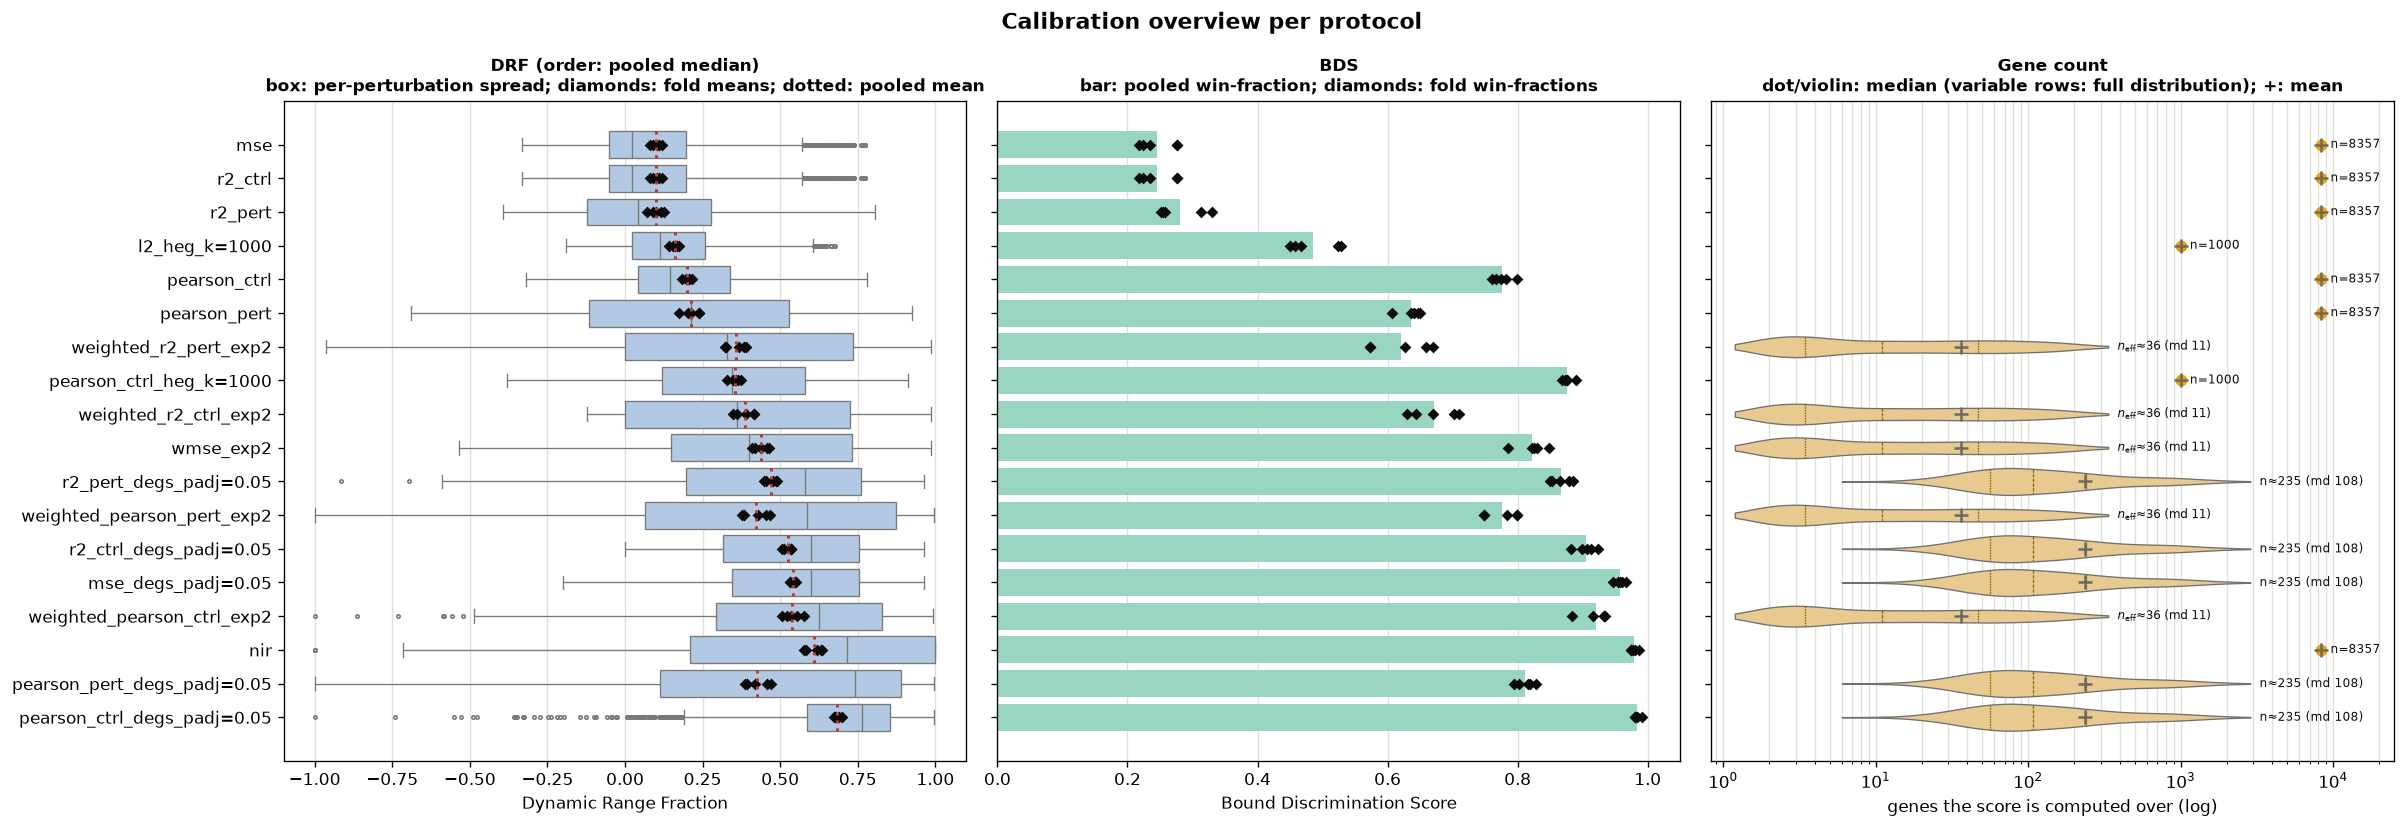

In [8]:
plot_calibration_overview(per_pert_calib, gene_counts)

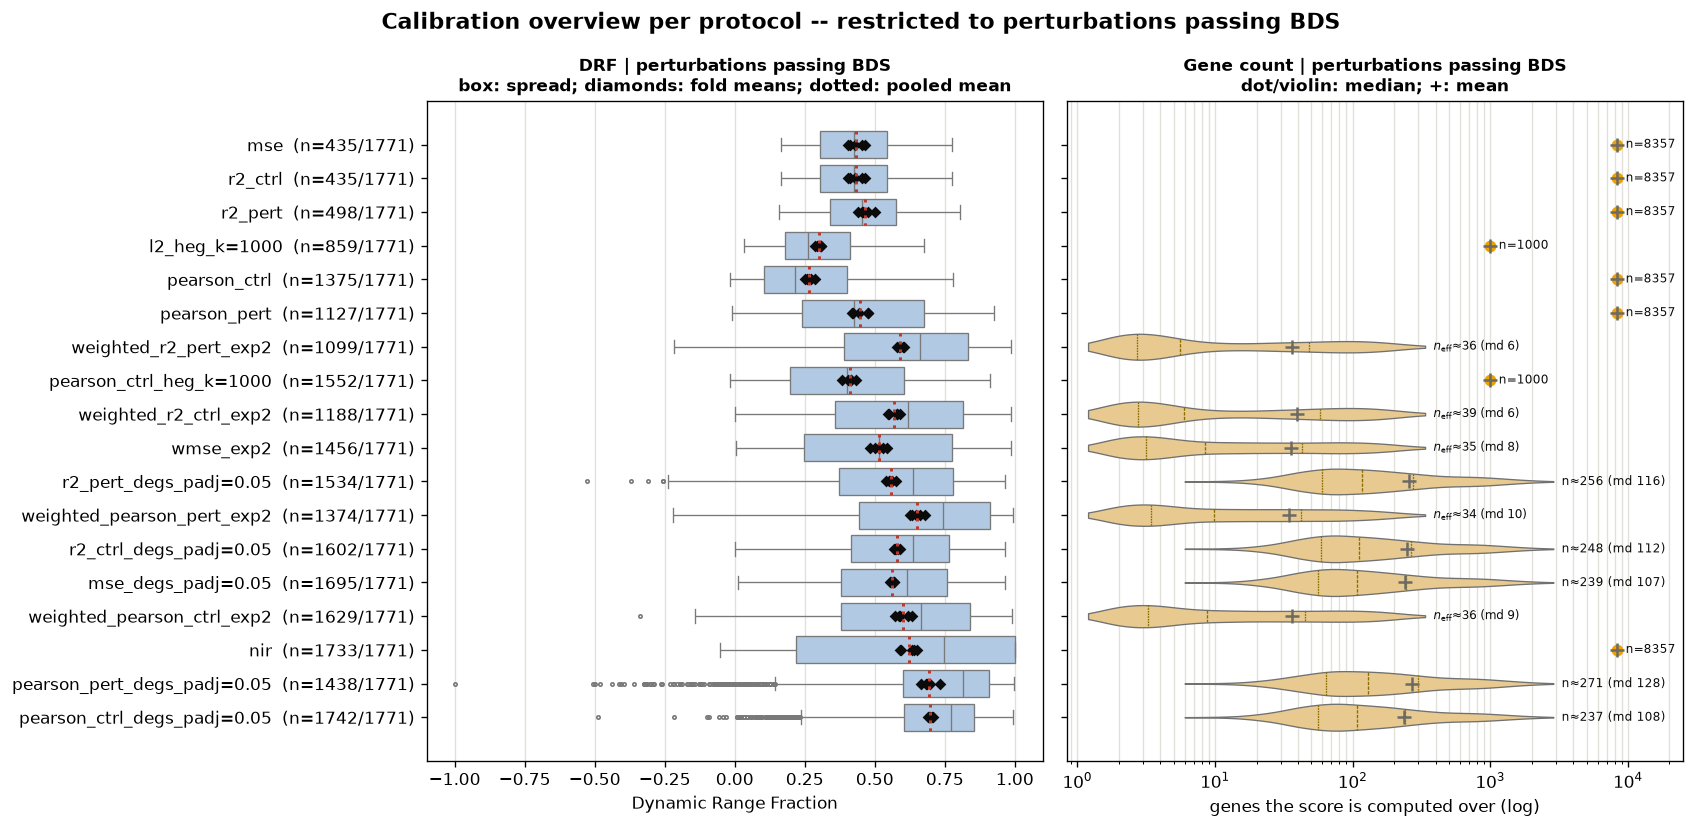

In [9]:
plot_calibration_overview(per_pert_calib, gene_counts, bds_filter=True)

**Interpretations:** 

- A protocol with a high $\mathrm{DRF}$ means that the protocol is able to perceive the interpolated duplicate as a genuine improvement over the negative baseline and associate it to the ideal predictor. Protocols that doesn't have a high $\mathrm{DRF}$ can therefore be hardly trusted as it means that even oracle predictions cannot be deciphered from the background perturbed mean. 
- A high $\mathrm{BDS}$ means that under the studied protocol the technical duplicate is thought to be more similar to the ground truth than it is to a negative baseline like the perturbed mean. Protocol with low $\mathrm{BDS}$ cannot even spot the technical duplicate (supposedly best prediction) as being any good. They shouldn't be trusted either. 
- Gene count is only here for transparency: protocol with both high gene count and high calibration on the two preceding criteria means they can still detect signal even though they are looking at a very noisy transcriptional state (many genes). A low effective gene count indicates that signal can be spot but only on very narrow view.

Given those criteria, we can notice:
1. $\mathrm{DEG}$ / weighted protocols are always better than their full space counterpart. 
2. Additionally $\mathrm{DEG}$ restricted metric is also usually better than their weighted counterpart while also retaining a higher effective gene count. 
   &rarr; weighted metrics over-emphasize on very few effective genes. On this restricted set, the `interpolated` baseline is pretty much equivalent to the `technical_duplicate`. It means that this discrepancy in calibration might be due to simple sample variance between the halves $a^{(1)}$, $a^{(2)}$ and that any distance capturing such variance is inflated with the weight. This might be worth further analysis. 
3. Control-centering reliably tightens the per-perturbation spread across every family, and raises the median in most (4/6) families, but for the plain, unrestricted $R^2$ / $\mathrm{Pearson}$ metrics specifically, pert-centering actually has a higher median $\mathrm{DRF}$. A plausible explanation though could be that we actually compute the $\mathrm{DEG}$ / weighted metric with respect to the all perturbed mean hence leading to such artifacts. Either way the difference doesn't seem very significant (needs to be checked). Independently of the calibration numbers, control-centering also has the nice property of being interpretable as $\text{log-Fold change}$.

**For transparency**, the same DRF and gene-count panels are shown above restricted to the perturbations where each protocol's own BDS check actually passes (positive control beats negative control) -- the subpopulation a protocol's BDS score claims it can discriminate on. This isn't folded into the interpretation above: a protocol's headline DRF/gene-count numbers should reflect its performance across every perturbation, not only the ones it already wins on. But whether DRF's shape (and the gene count it's computed over) shifts once restricted to BDS-passing perturbations is a useful cross-check on that headline view.

In [section 1.E.i](#i-mse-vs-pearson-vs-r2-per-gene-decomposition-of-the-drf), we propose to investigate the claim made at point 2 above. It is not strictly necessary for the purpose of the benchmark.

#### i. MSE vs. Pearson vs. R2: per-gene decomposition of the DRF
<!-- collapse-section: Click to expand -->

Point 2 above speculates that weighted metrics' shortfall against their DEG-restricted counterpart might be about over-emphasizing a handful of genes whose apparent signal is inflated by simple sample variance between the two split halves $a^{(1)}, a^{(2)}$. Let's explore this by decomposing the DRF signal on a per-gene basis. Let's recall some notations:

We are calibrating a metric $d(\cdot,\cdot)$ that scores how close a predicted (or baseline) gene expression profile is to a ground-truth profile, for a pool of perturbations $\mathcal{A}$ (size $|\mathcal{A}|$).

For a perturbation $a \in \mathcal{A}$:

- $X_{a^{(1)}}$: the ground-truth profile for $a$.
- $X^{\text{pos}}_a$: a **positive baseline** profile: a deliberately strong / near-optimal
  reference for $a$.
- $X^{\text{neg}}_a$: a **negative baseline** profile: a deliberately weak / uninformative
  reference for $a$.
- $G^a$: the set of genes affected by (or scored for) $a$, with $N_g^a = |G^a|$, which is scheme-specific:
  $a$'s DEG set for the uniformly-weighted formula, the full gene space for the real weighted one.

The $\operatorname{DRF}$ is therefore defined as:

$$
\operatorname{DRF}(a) = \frac{s_{\text{neg}}^{(a)} - s_{\text{pos}}^{(a)}}{s_{\text{neg}}^{(a)} - s_{\text{optim}} + \xi}
\quad
\text{and}
\quad
\operatorname{DRF} = \frac{1}{|\mathcal{A}|}\sum_a\operatorname{DRF}(a)
$$

Where:

$$
s_{\text{pos}}^{(a)} = d\big(X^{\text{pos}}_{a}, X_{a^{(1)}}\big), \qquad
s_{\text{neg}}^{(a)} = d\big(X^{\text{neg}}_{a}, X_{a^{(1)}}\big)
$$

Let's focus on the scoring function $d$: $\mathrm{MSE}$, $\mathrm{Pearson}$, $R^2$. Noting $Y_a$ either $X^{\text{pos}}_{a}$ or $X^{\text{neg}}_{a}$, we have:

$$
\mathrm{MSE}\left(Y_a, X_{a^{(1)}}\right) = \frac{1}{N_g^a}\sum_{g} \big(Y_{a,g} - X_{a^{(1)},g}\big)^2
$$

Where a per-gene squared errors can be defined as:

$$
e^\text{MSE}_{a,g} = \big(Y_{a,g} - X_{a^{(1)},g}\big)^2
\quad
\text{and}
\quad
\operatorname{DRF}(a)_g^{\text{MSE}, \{\text{pos},\text{neg}\}} = \frac{e^{\text{MSE}, \{\text{pos},\text{neg}\}}_{a,g}}{s_{\text{neg}}^{(a)} - s_{\text{optim}} + \xi}
$$

Similarly:

$$
\mathrm{Pearson}\left(Y_a, X_{a^{(1)}}\right) = \frac{\frac{1}{N^a_g}\sum_g (Y_{a,g} - \bar Y_a)(X_{a^{(1)},g} - \bar X_{a^{(1)}})}{D}
$$

With $D = \sqrt{\frac{1}{N^a_g}\sum_g (Y_{a,g} - \bar Y_a)^2 \cdot\frac{1}{N^a_g}\sum_g (X_{a^{(1)},g} - \bar X_{a^{(1)}})^2}$

A per-gene correlation can be defined as:

$$
e^\text{Pearson}_{a,g} = \frac{(Y_{a,g} - \bar Y_a)(X_{a^{(1)},g} - \bar X_{a^{(1)}})}{D}
\quad
\text{and}
\quad
\operatorname{DRF}(a)_g^{\text{Pearson}, \{\text{pos},\text{neg}\}} = \frac{e^{\text{Pearson}, \{\text{pos},\text{neg}\}}_{a,g}}{s_{\text{neg}}^{(a)} - s_{\text{optim}} + \xi}
$$

Finally,  

$$
\begin{align*}
R^2\left(Y_a, X_{a^{(1)}}\right) &= 1 - \frac{\frac{1}{N_g^a}\sum_{g} \big(Y_{a,g} - X_{a^{(1)},g}\big)^2}{\frac{1}{N^a_g}\sum_g (X_{a^{(1)},g} - \bar X_{a^{(1)}})^2}\\
&= \frac{\frac{1}{N_g^a}\sum_{g} (X_{a^{(1)},g} - \bar X_{a^{(1)}})^2 - \big(Y_{a,g} - X_{a^{(1)},g}\big)^2}{\frac{1}{N^a_g}\sum_g (X_{a^{(1)},g} - \bar X_{a^{(1)}})^2}
\end{align*}
$$

Where a per-gene coefficient of determination can be defined as:

$$
\begin{align*}
&e^\text{R2}_{a,g} = \frac{(X_{a^{(1)},g} - \bar X_{a^{(1)}})^2 - \big(Y_{a,g} - X_{a^{(1)},g}\big)^2}{\frac{1}{N^a_g}\sum_g (X_{a^{(1)},g} - \bar X_{a^{(1)}})^2}\\
\text{and} \quad & \operatorname{DRF}(a)_g^{\text{R2}, \{\text{pos},\text{neg}\}} = \frac{e^{\text{R2}, \{\text{pos},\text{neg}\}}_{a,g}}{s_{\text{neg}}^{(a)} - s_{\text{optim}} + \xi}
\end{align*}
$$

> [!NOTE]
> We are interested in a per-gene contribution to the total DRF. We can therefore decide to bin individual gene contributions based on the weight attributed to each gene $w_g(a)$ according to Mejia weights. The formulas above are the special case $w_g(a) = 1/N_g^a$ on the DEG set; the real weighted protocols (`weighted_*_exp2`) use the continuous Mejia weight over the full gene space instead.

We bin on $\log_{10} \frac{w_g(a)}{\max_g w_g(a)}$ into $N_{BINS}+2$ bins (with $N_{BINS} = 60$):

$$
B_k =
\begin{cases}
\left[-6 + 6\dfrac{k-1}{N_{BINS}}; -6 + 6\dfrac{k}{N_{BINS}}\right), & k \in {1, \dots, N_{BINS}-1} \\
\left[-6 + 6\dfrac{N_{BINS}-1}{N_{BINS}}; \log_{10} 0.9\right), & k = N_{BINS} \\
\left[\log_{10} 0.9; \log_{10} 0.99\right), & k = N_{BINS}+1 \\
\left[\log_{10} 0.99; 0\right], & k = N_{BINS}+2
\end{cases}
$$

$$
G^a_k = \{\, g \in G^a : \log_{10} \frac{w_g(a)}{\max_g w_g(a)} \in B_k \,\}, \qquad N^a_{g,k} = |G^a_k|
$$

> [!NOTE]
> We bin on the rescaled weight to make weights between perturbations more comparable. For instance, let's take two perturbations and four weighted genes:
> - [0.5, 0.2, 0.05, 0.05] -> [1, 0.4, 0.1, 0.1]
> - [0.9, 0.05, 0.025, 0.025] -> [1, 0.055, 0.027, 0.027]
> 
> In this scenario, the un-scaled version is what matters to compute the actual DRF / weighted averages. However, when comparing the two perturbations together, a 0.05 accounts for a 10th of the importance compared to a 40th of the importance in the second perturbation. So when comparing perturbations together, the re-scaled version is what actually matters. 

Therefore, for a single perturbation, the per-gene sum splits exactly into an **occupancy** term (how many
genes fall in bin $k$) and an **intensity** term (average per-gene DRF *within* bin $k$):

$$
\operatorname{DRF}(a) = \sum_{k=0}^{N_{BINS}-1}
\underbrace{\frac{N^a_{g,k}}{N^a_g}}_{\displaystyle \pi^a_k \text{ (occupancy)}}
\cdot
\underbrace{\left(\frac{1}{N^a_{g,k}}\sum_{g\in G^a_k}\operatorname{DRF}(a)_g\right)}_{\displaystyle \mu^a_k \text{ (intensity)}}
$$

Equivalently, defining the **direct contribution** of bin $k$,

$$
C^a_k = \sum_{g\in G^a_k}\frac{\operatorname{DRF}(a)_g}{N^a_g} = \pi^a_k\,\mu^a_k, \qquad \sum_k C^a_k = \operatorname{DRF}(a)
$$

$C^a_k$ is an exact partition of the total, but it is **ambiguous**: a large $C^a_k$ could mean
"many genes, modest effect each" ($\pi^a_k$ large, $\mu^a_k$ small) or "few genes, large effect
each" ($\pi^a_k$ small, $\mu^a_k$ large). These are the extensive vs. intensive margins, and only
$\mu^a_k$ (occupancy-free) directly answers "are highly weighted genes intrinsically more potent,
per gene?"

> [!WARNING]
> In practice, $\operatorname{DRF}(a)$ is clipped to $[-1, 1]$, and (for the $R^2$-based $d$) $R^2$ itself is clipped to be $\ge -1$ before use. Write $\operatorname{DRF}_\text{raw}(a) := \frac{1}{N_g^a}\sum_g \operatorname{DRF}(a)_g$ for the per-gene sum above; once clipping happens, $\operatorname{DRF}(a) \neq \operatorname{DRF}_\text{raw}(a)$ in general. For $R^2$ specifically, a value computed *directly* (calling $R^2$ itself, floor included) can already equal the reported, clipped $\operatorname{DRF}(a)$, while $\operatorname{DRF}_\text{raw}(a)$ still doesn't, because $R^2$'s own floor isn't part of $e^{R2}_{a,g}$.
>
> Therefore, plotted quantities are rescaled by $\lambda(a) = \operatorname{DRF}_{\text{clipped}}(a)/\operatorname{DRF}_{\text{raw}}(a)$

We therefore want to plot:

- The per gene contribution $C^a_k$ (rescaled by $\lambda$)
- The per gene intensity $\mu^a_k$ (rescaled by $\lambda$): occupancy-free, so it answers "is a typical gene here individually potent" rather than "how much does this bin add up to."
- The gene weight distribution, the pooled occupancy $\pi_k$, one curve per weighting scheme rather than one shared curve, since $G^a$ itself differs by scheme.

In [ ]:
ctx = prepared._run_context()  # bare handle onto ctx.ds.cells(...) -- no protocol/metric call needed
control_mean = ctx.ds.control_mean()
XI = 1e-6  # matches scperteval.calibrators._drf_per_pert's own epsilon exactly

# log-uniform, plus two extra edges near the very top (0.9, 0.99). The x-axis below is the weight
# rescaled by its own max (see next comment), so every perturbation's single best gene sits at
# exactly 1.0 -- without a finer split there, that one wide top bin pools "the top gene of every
# perturbation" (~1,800 genes) together with a much smaller population of near-ties (~600), which
# reads as a spike out of nowhere rather than the two distinguishable populations they actually are.
N_BINS = 62
EDGES = np.sort(np.unique(np.concatenate([np.logspace(-6, 0, 61), [0.9, 0.99]])))
BIN_MID = np.sqrt(EDGES[:-1] * EDGES[1:])


def bin_sums(values, weight):
    """C^a_k: a bin's total (summed) contribution: C^a_k = n_k(a) * mu^a_k (occupancy count times mean per-gene intensity, see below)."""
    idx = np.clip(np.digitize(weight, EDGES) - 1, 0, N_BINS - 1)
    return np.bincount(idx, weights=values, minlength=N_BINS)


def bin_counts(weight):
    """n_k(a): how many of a's genes fall in bin k, the occupancy count behind pi^a_k = n_k/N_g."""
    idx = np.clip(np.digitize(weight, EDGES) - 1, 0, N_BINS - 1)
    return np.bincount(idx, minlength=N_BINS)


def _mse_terms(w, a, b):
    """Per-gene contribution to sum_g[w_g*(a_g-b_g)^2], sums to (weighted or plain) MSE itself."""
    return w * (a - b) ** 2


def _pearson_terms(w, X, Y):
    """Per-gene contribution to a weighted Pearson correlation, sums to weighted_pearson(X, Y; w)."""
    Xbar, Ybar = np.sum(w * X), np.sum(w * Y)
    dX, dY = X - Xbar, Y - Ybar
    Vx, Vy = np.sum(w * dX**2), np.sum(w * dY**2)
    if Vx <= 0 or Vy <= 0:
        return None
    return w * dX * dY / np.sqrt(Vx * Vy)


def _r2_terms(w, X, Y):
    """Per-gene contribution to weighted_r2(X, Y; w)

    this gene's own share of ground-truth variance that Y actually explains, which can go
    negative if Y does worse for this gene than predicting the weighted mean would.
    """
    Xbar = np.sum(w * X)
    SST = np.sum(w * (X - Xbar) ** 2)
    if SST <= 0:
        return None
    return w * ((X - Xbar) ** 2 - (X - Y) ** 2) / SST


wrows: list[pd.DataFrame] = []
for pert in de.statistic.index:
    stat = de.statistic.loc[pert].to_numpy()
    deg_mask = de.pvalue_adj.loc[pert].to_numpy() < 0.05
    N_g = int(deg_mask.sum())

    mejia_w = mejia_weights(stat, 2)
    if mejia_w.max() <= 0:
        continue
    # binning axis only, not the weight passed to _mse_terms/_pearson_terms/_r2_terms below:
    # w_g / max_g(w) == u_g^exp (mejia_weights' own pre-normalization min-max score), so every
    # perturbation's own top gene sits at exactly 1.0 regardless of how diffuse or concentrated
    # that perturbation is -- a raw (sum-to-1) weight of 0.05 means "dominant hit" in a
    # concentrated perturbation and "negligible" in a diffuse one, which makes bins hard to
    # compare across perturbations. Using this rescaled weight as the actual metric weight
    # instead would break the weighted average itself (sum_g w_g/max(w) = N_eff(a), a
    # perturbation-dependent scale factor, not 1), so it stays confined to the x-axis.
    mejia_w_rescaled = mejia_w / mejia_w.max()

    half1 = np.asarray(to_dense(ctx.ds.cells(pert, half="first"))).mean(0)
    # the REAL positive candidate DRF calibrates against -- the fold-restricted interpolated
    # duplicate (section 1.B), not the raw held-out half. Using the raw half was a deliberate
    # proxy earlier in this section; swapping in the real one is what closed most of the gap
    # between this reconstruction and `calib`'s own DRF mean (see the markdown below).
    positive = fold_positive[pert]
    pert_mean = fold_negative[pert]  # fold-restricted all_perturbed_mean -- DRF's negative candidate
    ctx.current_pert = pert  # weighted_* metrics re-derive their own weight via ctx.de(...) internally

    schemes = [("mejia (exp=2)", mejia_w, {})]
    if N_g > 0:
        # "unweighted, DEG-restricted" IS a weighted metric: weight = 1/N_g on the DEG set, 0
        # elsewhere -- same machinery as the real Mejia weight below, just a different weight shape.
        uniform_w = deg_mask.astype(float) / N_g
        schemes.append(("uniform (DEG-restricted)", uniform_w, {"mask": deg_mask}))

    for weighting, w, opts in schemes:
        mask = opts.get("mask")
        # Occupancy is scheme-specific, not shared: a non-DEG gene carries exactly 0 weight under
        # "uniform (DEG-restricted)", so it isn't really part of that scheme's gene space at all --
        # counting it anyway would dilute mu/pi with genes that never contribute. DEGs are only
        # ~2.8% of all genes and sit at systematically higher rescaled weight, so this isn't a
        # small correction: pooled occupancy peaks around w~7e-4 restricted to DEGs vs. w~1e-6
        # over all genes, and the two only converge above w~0.3, where virtually every remaining
        # gene is already a DEG.
        if mask is not None:
            n_k = bin_counts(mejia_w_rescaled[mask])
            N_g_total = int(mask.sum())
        else:
            n_k = bin_counts(mejia_w_rescaled)
            N_g_total = len(mejia_w_rescaled)
        # Denominators use the REAL calibrated-protocol metric for this weighting scheme -- plain
        # mse/pearson/r2 restricted to DEGs for "uniform" (matches e.g. mse_degs_padj=0.05), the
        # real weighted_*_exp2 for "mejia" (matches e.g. wmse_exp2) -- so `C` stays DRF-consistent.
        mse_fn = (
            (lambda a, b: M.mse(a[mask], b[mask], ctx))  # noqa: B023
            if mask is not None
            else (lambda a, b: M.weighted_mse(a, b, ctx, exp=2.0))
        )
        pearson_fn = (
            (lambda a, b: M.pearson(a[mask], b[mask], ctx))  # noqa: B023
            if mask is not None
            else (lambda a, b: M.weighted_pearson(a, b, ctx, exp=2.0))
        )
        r2_fn = (
            (lambda a, b: M.r2(a[mask], b[mask], ctx))  # noqa: B023
            if mask is not None
            else (lambda a, b: M.weighted_r2(a, b, ctx, exp=2.0))
        )

        neg_mse, pos_mse = mse_fn(half1, pert_mean), mse_fn(half1, positive)
        den_mse = neg_mse + XI
        if den_mse > 0:
            # exact, raw/unclipped DRF(a) for this family/centering/weighting -- the same
            # numerator/denominator `_drf_per_pert` uses, just without its outer [-1, 1] clip
            # (see the markdown below for what that clip changes).
            DRF_a = (neg_mse - pos_mse) / den_mse
            for comparison, target in [("vs_positive", positive), ("vs_negbaseline", pert_mean)]:
                terms = _mse_terms(w, half1, target) / den_mse
                wrows.append(
                    pd.DataFrame(
                        {
                            "perturbation": pert,
                            "family": "mse",
                            "centering": "none",
                            "weighting": weighting,
                            "comparison": comparison,
                            "bin_mid": BIN_MID,
                            "C": bin_sums(terms, mejia_w_rescaled),
                            "n_k": n_k,
                            "N_g_total": N_g_total,
                            "DRF_a": DRF_a,
                        }
                    )
                )

        for name, c in [("ctrl", control_mean), ("pert", pert_mean)]:
            # A pert-centered metric's negative candidate switches to control (section 1.B) --
            # centering on all_perturbed_mean would otherwise make it collapse to exactly 0.
            negbaseline_target = control_mean if name == "pert" else pert_mean
            X = half1 - c

            neg_pearson, pos_pearson = pearson_fn(X, negbaseline_target - c), pearson_fn(X, positive - c)
            den_pearson = (1.0 - neg_pearson) + XI
            DRF_a_pearson = (pos_pearson - neg_pearson) / den_pearson

            neg_r2, pos_r2 = r2_fn(X, negbaseline_target - c), r2_fn(X, positive - c)
            den_r2 = (1.0 - neg_r2) + XI
            DRF_a_r2 = (pos_r2 - neg_r2) / den_r2

            for comparison, target in [("vs_positive", positive), ("vs_negbaseline", negbaseline_target)]:
                Y = target - c
                if den_pearson > 0:
                    p_terms = _pearson_terms(w, X, Y)
                    if p_terms is not None:
                        wrows.append(
                            pd.DataFrame(
                                {
                                    "perturbation": pert,
                                    "family": "pearson",
                                    "centering": name,
                                    "weighting": weighting,
                                    "comparison": comparison,
                                    "bin_mid": BIN_MID,
                                    "C": bin_sums(p_terms / den_pearson, mejia_w_rescaled),
                                    "n_k": n_k,
                                    "N_g_total": N_g_total,
                                    "DRF_a": DRF_a_pearson,
                                }
                            )
                        )
                if den_r2 > 0:
                    r_terms = _r2_terms(w, X, Y)
                    if r_terms is not None:
                        wrows.append(
                            pd.DataFrame(
                                {
                                    "perturbation": pert,
                                    "family": "r2",
                                    "centering": name,
                                    "weighting": weighting,
                                    "comparison": comparison,
                                    "bin_mid": BIN_MID,
                                    "C": bin_sums(r_terms / den_r2, mejia_w_rescaled),
                                    "n_k": n_k,
                                    "N_g_total": N_g_total,
                                    "DRF_a": DRF_a_r2,
                                }
                            )
                        )

per_gene = pd.concat(wrows, ignore_index=True)

# pi (occupancy), mu (intensity), rho (share): C^a_k = n_k(a) * mu^a_k = N_g_total(a) * pi^a_k *
# mu^a_k is an exact identity for every row; rho^a_k = C^a_k / DRF_a normalizes across
# perturbations of different overall magnitude before pooling (see the markdown below for why
# that matters -- a raw pooled sum of C over-weights perturbations with large |DRF_a|).
per_gene["pi"] = per_gene["n_k"] / per_gene["N_g_total"]
per_gene["mu"] = per_gene["C"] / per_gene["n_k"].replace(0, np.nan)
per_gene["rho"] = per_gene["C"] / per_gene["DRF_a"].replace(0, np.nan)

# (family, centering, weighting) -> the real calibrated protocol it corresponds to, so the legend
# can show summing this curve's bins against that protocol's own real DRF mean.
PROTOCOL_MAP = {
    ("mse", "none", "uniform (DEG-restricted)"): "mse_degs_padj=0.05",
    ("pearson", "ctrl", "uniform (DEG-restricted)"): "pearson_ctrl_degs_padj=0.05",
    ("pearson", "pert", "uniform (DEG-restricted)"): "pearson_pert_degs_padj=0.05",
    ("r2", "ctrl", "uniform (DEG-restricted)"): "r2_ctrl_degs_padj=0.05",
    ("r2", "pert", "uniform (DEG-restricted)"): "r2_pert_degs_padj=0.05",
    ("mse", "none", "mejia (exp=2)"): "wmse_exp2",
    ("pearson", "ctrl", "mejia (exp=2)"): "weighted_pearson_ctrl_exp2",
    ("pearson", "pert", "mejia (exp=2)"): "weighted_pearson_pert_exp2",
    ("r2", "ctrl", "mejia (exp=2)"): "weighted_r2_ctrl_exp2",
    ("r2", "pert", "mejia (exp=2)"): "weighted_r2_pert_exp2",
}


def _signed_gap(family, positive, negbaseline):
    """Enforce the lower/higher is better convention. mse: lower, the rest higher."""
    return (negbaseline - positive) if family == "mse" else (positive - negbaseline)


def _attach_rescaled_columns(df: pd.DataFrame) -> pd.DataFrame:
    """lambda(a) = real DRF(a) / this section's own naive per-gene-term total for that perturbation

    corrects for every nonlinearity our per-gene decomposition can't replicate in one shot.
    """
    lam_parts: list[pd.DataFrame] = []
    for (family, centering, weighting), protocol in PROTOCOL_MAP.items():
        d = df[(df["family"] == family) & (df["centering"] == centering) & (df["weighting"] == weighting)]
        csum = d.groupby(["perturbation", "comparison"])["C"].sum().unstack("comparison")
        csum_total = _signed_gap(family, csum["vs_positive"], csum["vs_negbaseline"])
        real = per_pert_calib.loc[
            (per_pert_calib["calibrator"] == "drf") & (per_pert_calib["protocol"] == protocol)
        ].set_index("perturbation")["value"]
        lam = (real / csum_total).rename("lam")
        lam_parts.append(lam.to_frame().assign(family=family, centering=centering, weighting=weighting))
    lam_df = pd.concat(lam_parts).reset_index()
    out = df.merge(lam_df, on=["perturbation", "family", "centering", "weighting"], how="left")
    out["C_rescaled"] = out["C"] * out["lam"]
    out["mu_rescaled"] = out["mu"] * out["lam"]
    return out


per_gene = _attach_rescaled_columns(per_gene)

In [ ]:
import matplotlib.ticker as mticker


_FAMILIES = [("mse", ["none"]), ("pearson", ["ctrl", "pert"]), ("r2", ["ctrl", "pert"])]
_CENTERING_COLORS = {"none": "#555555", "ctrl": "#1f6f8b", "pert": "#c1440e"}
_CENTERING_LABELS = {"none": "", "ctrl": "ctrl-centered", "pert": "pert-centered"}
_WEIGHTING_STYLES = {"uniform (DEG-restricted)": "--", "mejia (exp=2)": "-"}
_WEIGHT_XLABEL = "Mejia weight, rescaled by max: w_g / max_g(w) (log)"
# 3.548e-05 is where cumulative |contribution| first reaches 0.1% of its own total (computed from
# the data); 1.3 gives the top-bin spike room to breathe instead of sitting on the plot border.
_WEIGHT_XLIM = (3.548e-05, 1.3)


def _label_prefix(centering, sep=": "):
    """`_CENTERING_LABELS["none"]` is "" (mse has only one centering, not worth naming)

    this keeps the separator from leaking into the legend as a leading ": " or ", " when it's empty.
    """
    label = _CENTERING_LABELS[centering]
    return f"{label}{sep}" if label else ""


_GAP_ROW_COLORS = {
    ("none", "uniform (DEG-restricted)"): "#b39ddb",  # mse, unweighted -- light purple
    ("none", "mejia (exp=2)"): "#4a2e83",  # mse, weighted -- dark purple
    ("ctrl", "uniform (DEG-restricted)"): "#7fb3d3",  # ctrl, unweighted -- light blue
    ("ctrl", "mejia (exp=2)"): "#1a4f6e",  # ctrl, weighted -- dark blue
    ("pert", "uniform (DEG-restricted)"): "#e8956a",  # pert, unweighted -- light red
    ("pert", "mejia (exp=2)"): "#8c2f12",  # pert, weighted -- dark red
}


def _draw_gap_row(ax, df, value_col, family, centerings):
    """The actual per-bin DRF contribution: vs_positive and vs_negbaseline's signed difference"""
    for weighting in _WEIGHTING_STYLES:
        d = df[(df["family"] == family) & (df["weighting"] == weighting)]
        for centering in centerings:
            dd = d[d["centering"] == centering]
            piv = dd.pivot_table(index=["perturbation", "bin_mid"], columns="comparison", values=value_col)
            gap = _signed_gap(family, piv["vs_positive"], piv["vs_negbaseline"]).rename("gap").reset_index()
            mean_curve = gap.groupby("bin_mid")["gap"].mean()
            color = _GAP_ROW_COLORS[(centering, weighting)]
            ax.plot(
                mean_curve.index,
                mean_curve.to_numpy(),
                color=color,
                linewidth=2,
                label=f"{_label_prefix(centering, ', ')}{weighting}",
            )
    ax.axhline(0.0, color="#cccccc", linewidth=0.7)
    ax.set_xscale("log")
    ax.set_xlim(*_WEIGHT_XLIM)
    ax.legend(fontsize=6.5)


def _plot_weighted_metric_grid(
    df: pd.DataFrame,
    value_col: str,
    row_defs,
    legend_extra=None,
    suptitle: str = "",
    gap_row_label: str = "actual DRF contribution",
) -> None:
    """Shared grid machinery behind both `plot_per_gene_contribution` and `plot_per_gene_intensity`

    rows 1-2 are weighting scheme (top: uniform DEG-restricted, bottom: real Mejia) x 3 columns of
    metric family, top row sets one shared y-axis (from the largest of its own three families),
    row 2 is forced onto that same scale with an inset wherever its own data overflows it.
    `value_col` picks which per-bin column to plot ("C_rescaled" for total contribution,
    "mu_rescaled" for mean per-gene intensity); `legend_extra(family, centering, weighting,
    curves)` optionally returns one more legend label per centering -- pass None to skip it.

    Row 3 is different in kind, not just in weighting: it plots the actual signed DRF
    contribution (plain mean across perturbations), uniform and Mejia weighting overlaid on the
    same axis per family, since that's the direct answer to "does weighting change the shape or
    just the scale."
    """
    fig, axes = plt.subplots(3, 3, figsize=(19, 16), sharex=True, sharey=False)
    colors = _CENTERING_COLORS
    families = _FAMILIES

    def _draw(ax, data, centerings, family, weighting, legend=True):
        for centering in centerings:
            color = colors.get(centering, "#6b6b6b")
            curves = {}
            for comparison in ["vs_positive", "vs_negbaseline"]:
                d = data[(data["centering"] == centering) & (data["comparison"] == comparison)]
                curves[comparison] = d.groupby("bin_mid")[value_col].mean().sort_index()
            x = curves["vs_positive"].index
            ax.plot(
                x,
                curves["vs_positive"].to_numpy(),
                color=color,
                linewidth=2,
                linestyle="-",
                label=f"{_label_prefix(centering)}vs positive",
            )
            ax.plot(
                x,
                curves["vs_negbaseline"].to_numpy(),
                color=color,
                linewidth=2,
                linestyle="--",
                label=f"{_label_prefix(centering)}vs neg. candidate",
            )
            ax.fill_between(
                x, curves["vs_positive"].to_numpy(), curves["vs_negbaseline"].to_numpy(), color=color, alpha=0.15
            )

            if legend and legend_extra is not None:
                extra = legend_extra(family, centering, weighting, curves)
                if extra is not None:
                    ax.plot([], [], linestyle="none", label=f"{_label_prefix(centering)}{extra}")
        if legend:
            ax.legend(fontsize=7)

    # pass 1: draw every top-row panel, so the shared scale reflects the largest of the three
    # families rather than any single one.
    row0_ylims = []
    for col, (family, centerings) in enumerate(families):
        ax0 = axes[0, col]
        d0 = df[(df["family"] == family) & (df["weighting"] == row_defs[0][0])]
        _draw(ax0, d0, centerings, family, row_defs[0][0])
        ax0.set_xscale("log")
        ax0.set_xlim(*_WEIGHT_XLIM)
        ax0.set_title(family, fontsize=11, fontweight="bold")
        ax0.set_ylabel(row_defs[0][1], fontsize=9)
        row0_ylims.append(ax0.get_ylim())
    shared_ylim = (min(y[0] for y in row0_ylims), max(y[1] for y in row0_ylims))
    for col in range(len(families)):
        axes[0, col].set_ylim(shared_ylim)

    # pass 2: middle row, forced onto that same shared scale, with an inset wherever a family's
    # own data overflows it.
    for col, (family, centerings) in enumerate(families):
        ax1 = axes[1, col]
        d1 = df[(df["family"] == family) & (df["weighting"] == row_defs[1][0])]
        _draw(ax1, d1, centerings, family, row_defs[1][0])
        ax1.set_xscale("log")
        ax1.set_xlim(*_WEIGHT_XLIM)
        if col == 0:
            ax1.set_ylabel(row_defs[1][1], fontsize=9)

        # how far row 1's own data actually reaches, ignoring the shared scale it's forced onto
        d1_max = max(
            d1[(d1["centering"] == c) & (d1["comparison"] == comp)].groupby("bin_mid")[value_col].mean().max()
            for c in centerings
            for comp in ["vs_positive", "vs_negbaseline"]
        )
        ax1.set_ylim(shared_ylim)
        if d1_max > shared_ylim[1] * 1.05:
            # zoom the inset to just the clipped corner -- the bins that actually overflow the
            # main panel's y-limit, not a redundant full redraw of the whole (mostly-visible) curve
            all_bins = sorted(d1["bin_mid"].unique())
            overflow_bins = set()
            for c in centerings:
                for comp in ["vs_positive", "vs_negbaseline"]:
                    curve = d1[(d1["centering"] == c) & (d1["comparison"] == comp)].groupby("bin_mid")[value_col].mean()
                    overflow_bins |= set(curve.index[curve > shared_ylim[1]])
            first_overflow_idx = all_bins.index(min(overflow_bins))
            x_lo = all_bins[max(first_overflow_idx - 1, 0)]  # one bin of context before the overflow starts
            x_hi = all_bins[-1]

            ax_inset = ax1.inset_axes([0.06, 0.38, 0.40, 0.50])
            _draw(ax_inset, d1, centerings, family, row_defs[1][0], legend=False)
            ax_inset.set_xscale("log")
            ax_inset.set_xlim(x_lo * 0.6, x_hi * 1.5)
            # Anchor the peak at the range's 75th percentile,
            # so it always sits with the same comfortable headroom above it, however tall it is.
            inset_ymin = shared_ylim[1] * 0.85
            inset_ymax = inset_ymin + (d1_max - inset_ymin) / 0.75
            ax_inset.set_ylim(inset_ymin, inset_ymax)
            # cap at a handful, evenly spaced across the bins actually being displayed,
            # rather than labeling every single one of them
            N_MAX_INSET_TICKS = 5
            shown_bins = [b for b in all_bins if x_lo * 0.6 <= b <= x_hi * 1.5]
            if len(shown_bins) > N_MAX_INSET_TICKS:
                idx = sorted(set(np.linspace(0, len(shown_bins) - 1, N_MAX_INSET_TICKS).round().astype(int)))
                tick_bins = [shown_bins[i] for i in idx]
            else:
                tick_bins = shown_bins
            ax_inset.xaxis.set_minor_locator(mticker.NullLocator())  # log-scale minor ticks/labels
            ax_inset.xaxis.set_minor_formatter(mticker.NullFormatter())  # would otherwise still crowd in
            ax_inset.set_xticks(tick_bins)
            ax_inset.set_xticklabels([f"{b:.0e}" for b in tick_bins])
            ax_inset.tick_params(labelsize=6)
            ax_inset.set_title("zoom: clipped corner", fontsize=6.5, color="#888888", pad=2)
            for spine in ax_inset.spines.values():
                spine.set_edgecolor("#888888")

    # pass 3: the actual signed DRF contribution, both weighting schemes overlaid, median + IQR
    for col, (family, centerings) in enumerate(families):
        ax2 = axes[2, col]
        _draw_gap_row(ax2, df, value_col, family, centerings)
        ax2.set_xlabel(_WEIGHT_XLABEL)
        if col == 0:
            ax2.set_ylabel(f"{gap_row_label}\n(mean across perturbations)", fontsize=9)

    fig.suptitle(suptitle)
    plt.tight_layout()


def plot_per_gene_contribution(df: pd.DataFrame) -> None:
    """Per-gene contribution to DRF's own numerator, rescaled by DRF's own denominator, decomposed by rescaled-weight bin."""

    def _legend_extra(family, centering, weighting, curves):
        protocol = PROTOCOL_MAP.get((family, centering, weighting))
        if protocol is None:
            return None
        total = _signed_gap(family, curves["vs_positive"].to_numpy(), curves["vs_negbaseline"].to_numpy()).sum()
        real_mean = calib.loc[(calib["protocol"] == protocol) & (calib["calibrator"] == "drf"), "mean"].iloc[0]
        return f"Σbins={total:.3f} vs DRF mean={real_mean:.3f}"

    row_defs = [
        ("uniform (DEG-restricted)", "DEG-restricted, uniform weight\n(the real unweighted formula)"),
        ("mejia (exp=2)", "full gene space, real Mejia weight\n(the real weighted_*_exp2 formula)"),
    ]
    _plot_weighted_metric_grid(
        df,
        value_col="C_rescaled",
        row_defs=row_defs,
        legend_extra=_legend_extra,
        suptitle=(
            "MSE vs. Pearson vs. R2: per-bin contribution to DRF's numerator, rescaled by DRF's own denominator (lambda-corrected)\n"
            "rows 1-2: uniform (DEG-restricted) vs. real Mejia weight (same y-scale; inset = full range)  |  row 3: actual signed contribution, both overlaid"
        ),
    )


def plot_per_gene_intensity(df: pd.DataFrame) -> None:
    """Twin of `plot_per_gene_contribution` above, plotting mean per-gene intensity (`mu_rescaled`)

    instead of total contribution (`C_rescaled`). C^a_k = n_k(a) * mu^a_k: a bin's total
    contribution is occupancy (how many genes live there, see `plot_gene_weight_distribution`
    below) times intensity (the average contribution of the genes that do) -- C alone can't tell
    those two apart, since a bin can look big either because it holds many modestly-informative
    genes, or because a few genes there are each individually decisive.
    """
    row_defs = [
        ("uniform (DEG-restricted)", "mean per-gene contribution μ\nDEG-restricted, uniform weight"),
        ("mejia (exp=2)", "mean per-gene contribution μ\nfull gene space, real Mejia weight"),
    ]
    _plot_weighted_metric_grid(
        df,
        value_col="mu_rescaled",
        row_defs=row_defs,
        legend_extra=None,
        gap_row_label="actual per-gene intensity",
        suptitle=(
            "MSE vs. Pearson vs. R2: mean per-gene contribution (μ) within each weight bin -- occupancy-free, unlike the sum-based plot above\n"
            "rows 1-2: uniform (DEG-restricted) vs. real Mejia weight (same y-scale; inset = full range)  |  row 3: actual signed intensity, both overlaid"
        ),
    )


def plot_gene_weight_distribution(df: pd.DataFrame) -> None:
    """Where the pool's genes actually sit across the rescaled Mejia weight

    Raw pooled gene count (summed across perturbations), not a proportion -- log y-axis, since the
    two schemes differ by 100x+ at low weight (DEGs are ~2.8% of all genes) and only converge
    above w~0.3 (virtually every remaining gene is already a DEG), both of which a proportion view
    (each curve independently normalized to its own scheme total) hides. Unlike the two plots
    above, this one keeps the full range down to 1e-6 -- genes below the shaded cutoff exist in
    large numbers, they just don't move DRF, which is the point being made here.
    """
    counts = df.drop_duplicates(["perturbation", "bin_mid", "weighting"])[["bin_mid", "weighting", "n_k"]]
    totals = counts.groupby(["weighting", "bin_mid"])["n_k"].sum()

    colors = {"uniform (DEG-restricted)": "#c1440e", "mejia (exp=2)": "#555555"}
    _fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for weighting, color in colors.items():
        curve = totals.loc[weighting].sort_index()
        ax.plot(curve.index, curve.to_numpy(), color=color, linewidth=2, label=weighting)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.axvspan(ax.get_xlim()[0], _WEIGHT_XLIM[0], color="gray", alpha=0.15, zorder=0)
    ax.text(
        np.sqrt(ax.get_xlim()[0] * _WEIGHT_XLIM[0]),
        np.sqrt(ax.get_ylim()[0] * ax.get_ylim()[1]),
        "genes here barely\ncontribute to DRF\n(<0.1% of total)",
        fontsize=7.5,
        color="#555555",
        ha="center",
        va="center",
    )
    ax.set_xlabel(_WEIGHT_XLABEL)
    ax.set_ylabel("pooled gene count (raw, log)")
    ax.set_title("Where genes actually sit across the rescaled weight range (pooled across all perturbations)")
    ax.legend(fontsize=8)
    plt.tight_layout()

Finally, showing individual gene contribution or intensity to the total DRF binned by gene weight might not give the complete picture. 

Recall that: $w_{g,a} = \mathrm{Mejia}_{weight}\left(\left(s_{g,a}\right)_{g\in\mathcal{G}}, \exp\right)$. The weight $w_{g,a}$ is a rescaled version of the true effect size on gene $g$ for a given perturbation $a$: $s_{g,a}$

We propose to show $\max_g s_{g,a}$ against $N^{eff}_a$, which by definition of the Mejia weights reduces to $N^{eff}_a = \frac{1}{\max_g w_{g,a}}$, colored by the sign of $\mathrm{DRF}_{weighted} - \mathrm{DRF}_{\mathrm{DEG}, p_{adj}<0.05}$, where a positive value means that the weighting is helpful and a negative value indicates it is not.

See below for full motivation / interpretation. 

In [ ]:
def plot_effect_concentration(df: pd.DataFrame) -> None:
    """N_eff(a) = 1/max_g w_g,a (concentration) vs. the strongest per-gene effect size

    Colored three ways:

    1. whether weighting helps or hurts (DRF_gap)
    2. how many DEGs the perturbation has (N_g)
    3. and how many cells it was profiled with (n_cells)

    n_cells matters here because Welch's t-statistic's denominator is an *estimated* per-gene
    variance: with few cells that estimate is noisy, and by chance some gene's variance gets
    underestimated, inflating its |stat|: exactly the kind of artifact an extreme-value
    statistic like max_g|s_g,a| is vulnerable to. The n_cells panel is what lets you tell a
    genuinely concentrated, strong effect apart from a low-cell-count perturbation where one
    gene's statistic is inflated by sampling noise rather than biology.
    """
    rows = []
    for pert in de.statistic.index:
        stat = de.statistic.loc[pert].to_numpy()
        padj = de.pvalue_adj.loc[pert].to_numpy()
        finite = np.isfinite(stat) & np.isfinite(padj)
        w = mejia_weights(stat, 2)
        if w.max() <= 0:
            continue
        rows.append(
            {
                "perturbation": pert,
                "N_g": int((padj[finite] < 0.05).sum()),
                "max_abs_stat": np.abs(stat[finite]).max(),
                "n_eff": 1.0 / w[finite].max(),
                "n_cells": ctx.ds.cells(pert).shape[0],
            }
        )
    props = pd.DataFrame(rows).set_index("perturbation")

    mse_rows = df[df["family"] == "mse"]
    drf_a = mse_rows.drop_duplicates(["perturbation", "weighting"]).pivot(
        index="perturbation", columns="weighting", values="DRF_a"
    )
    drf_gap = (drf_a["mejia (exp=2)"] - drf_a["uniform (DEG-restricted)"]).rename("DRF_gap")

    plot_df = props.join(drf_gap, how="inner")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    vmax = plot_df["DRF_gap"].abs().max()
    sc0 = axes[0].scatter(
        plot_df["n_eff"],
        plot_df["max_abs_stat"],
        c=plot_df["DRF_gap"],
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        s=18,
        alpha=0.8,
        edgecolors="none",
    )
    fig.colorbar(sc0, ax=axes[0], label="DRF_weighted - DRF_unweighted (mse)\n(red = weighting helps, blue = hurts)")
    axes[0].set_title("colored by DRF gap")

    sc1 = axes[1].scatter(
        plot_df["n_eff"],
        plot_df["max_abs_stat"],
        c=plot_df["N_g"],
        cmap="viridis",
        norm="log",
        s=18,
        alpha=0.8,
        edgecolors="none",
    )
    fig.colorbar(sc1, ax=axes[1], label="N_g (log)")
    axes[1].set_title("colored by N_g")

    sc2 = axes[2].scatter(
        plot_df["n_eff"],
        plot_df["max_abs_stat"],
        c=plot_df["n_cells"],
        cmap="viridis",
        s=18,
        alpha=0.8,
        edgecolors="none",
    )
    fig.colorbar(sc2, ax=axes[2], label="n_cells")
    axes[2].set_title("colored by n_cells")

    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("N_eff(a) = 1 / max_g w_g,a (log)")
    axes[0].set_ylabel("max_g |s_g,a| (log)")

    fig.suptitle("Concentrated vs. diffuse effect, and whether weighting helps or hurts DRF (n=1,771 perturbations)")
    plt.tight_layout()

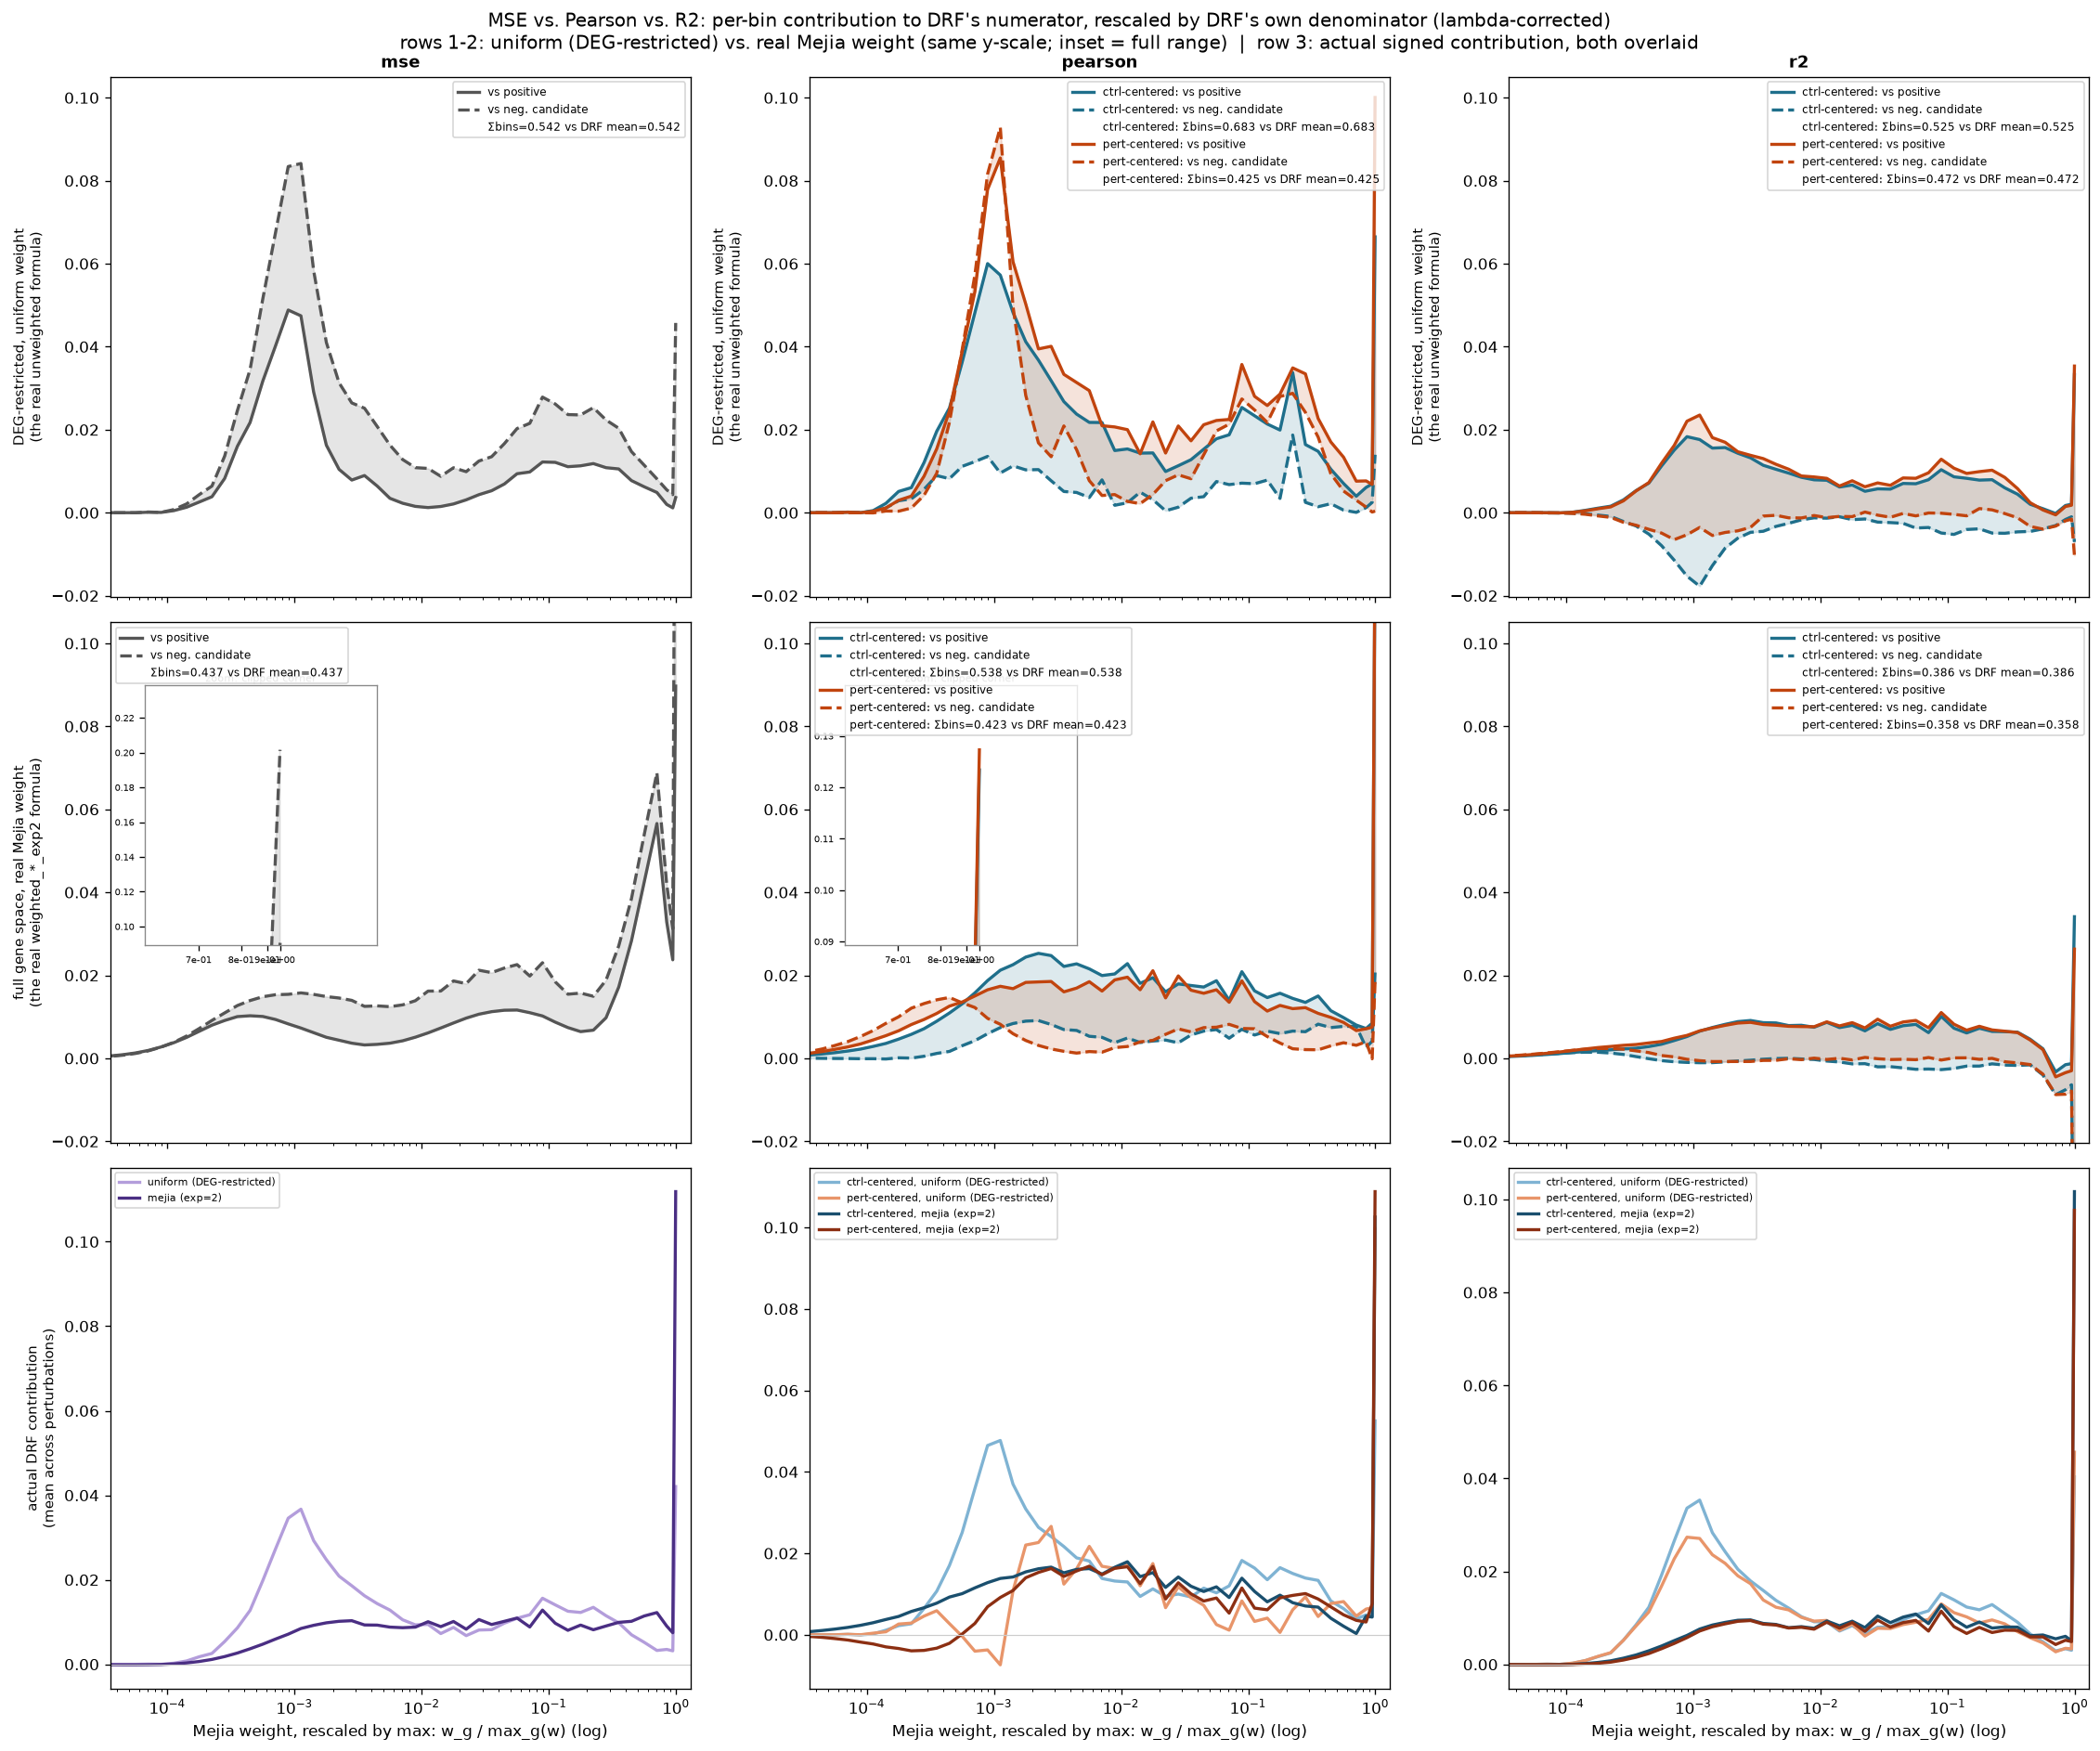

In [13]:
plot_per_gene_contribution(per_gene)

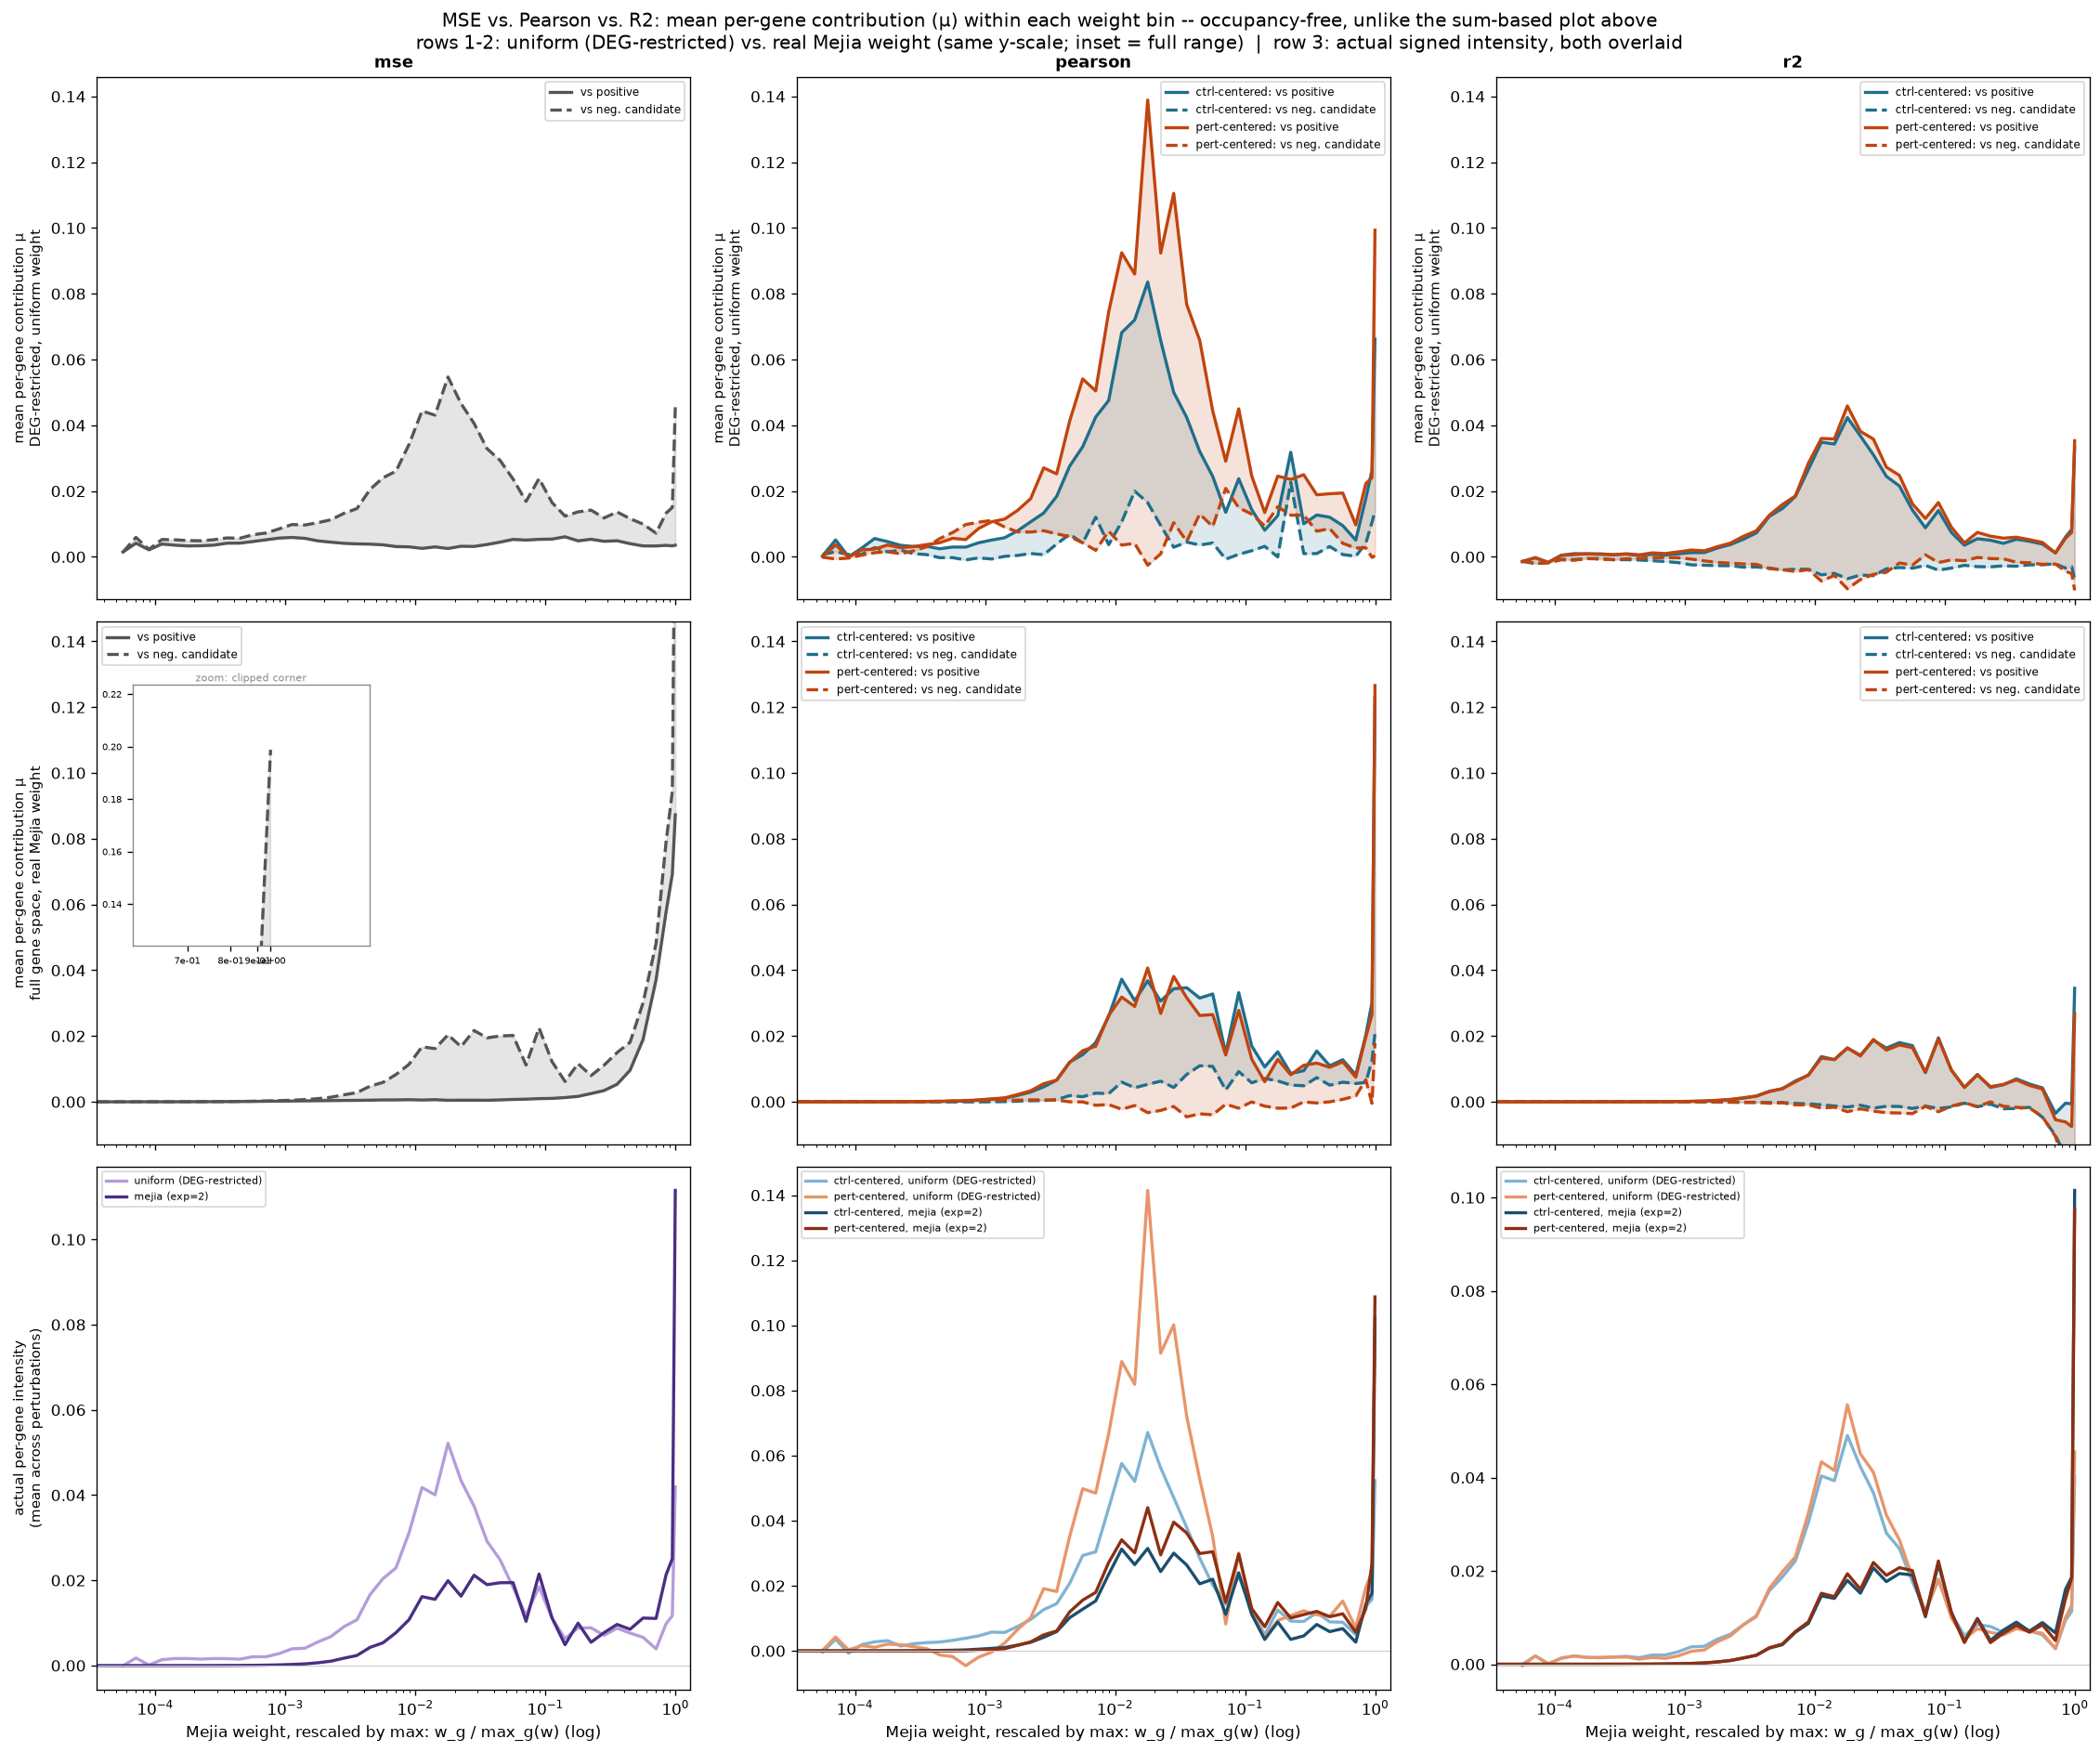

In [14]:
plot_per_gene_intensity(per_gene)

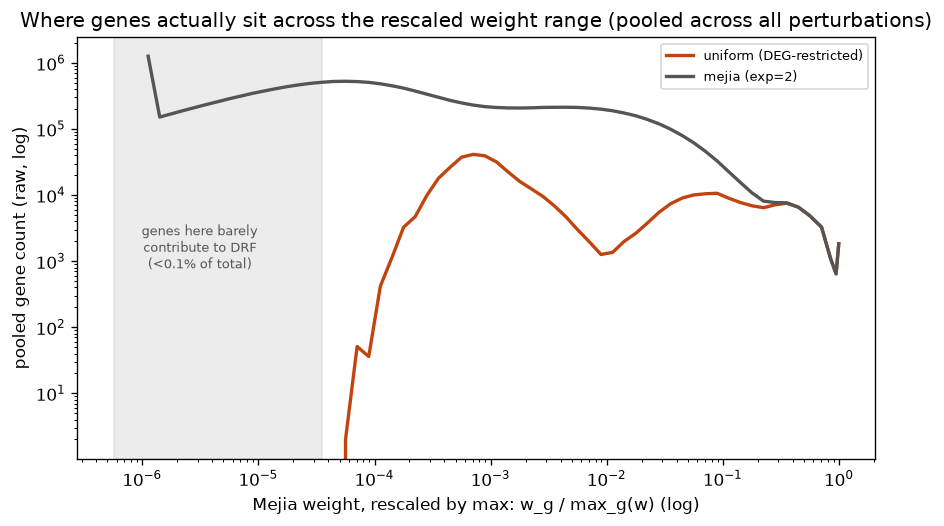

In [15]:
plot_gene_weight_distribution(per_gene)

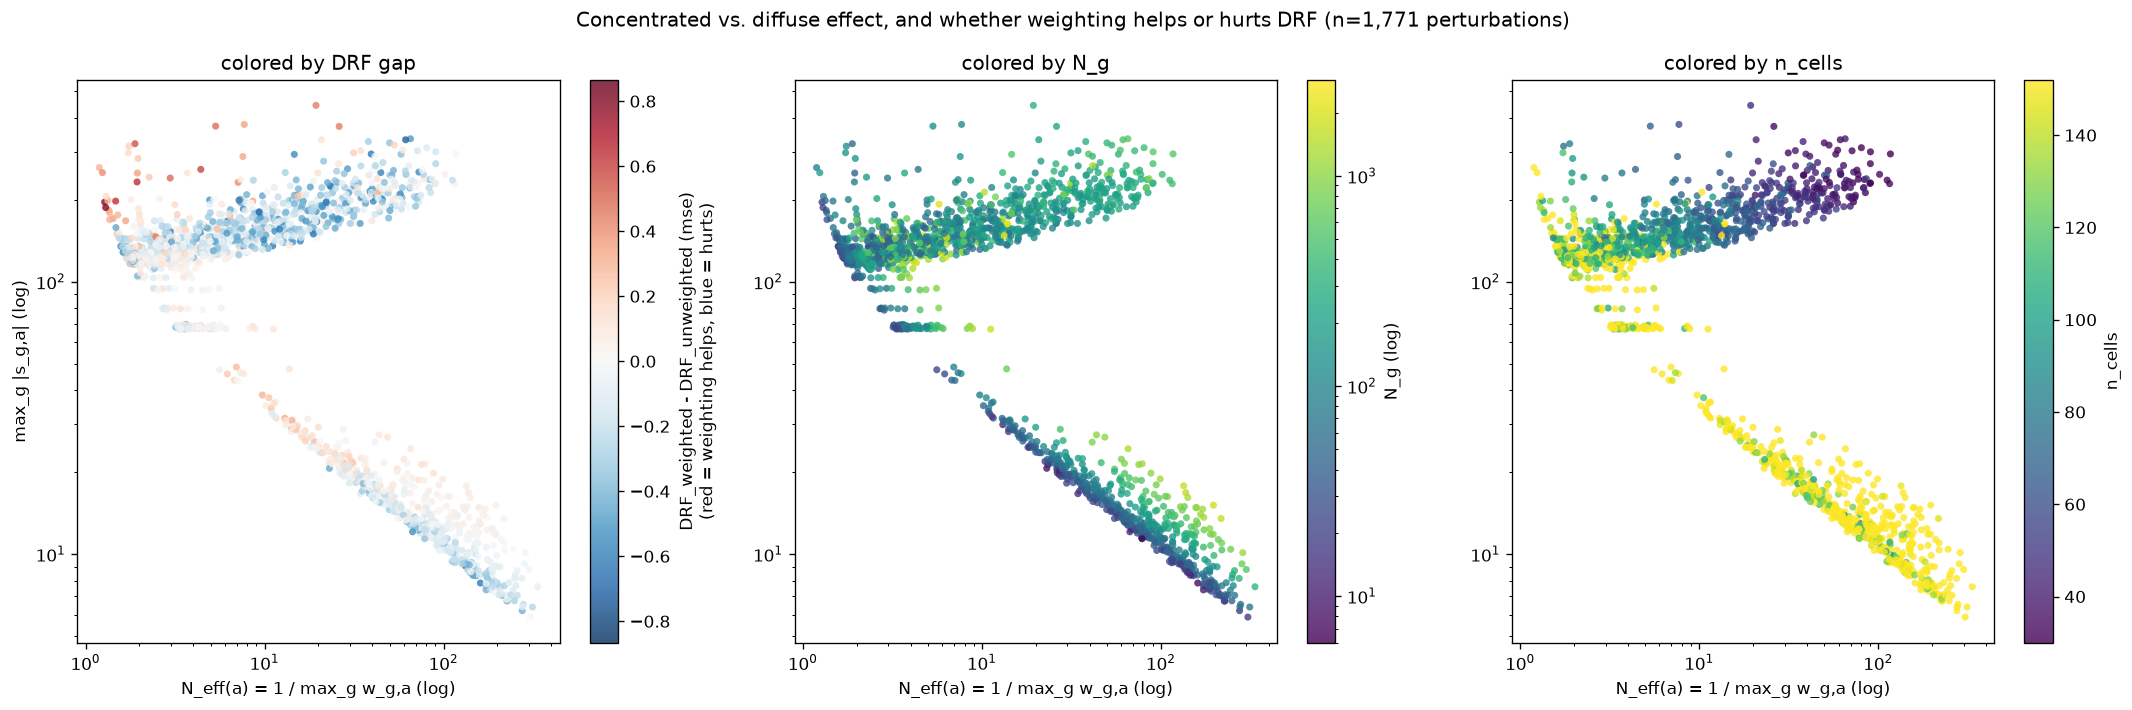

In [16]:
plot_effect_concentration(per_gene)

**Interpretation**:

- *Panel 1, Gene contribution* shows, for a given re-scaled gene weight, the total contribution across perturbation to the final $\text{DRF}$ score. Summing for every bin the difference between the plain and dotted curve result in the total mean $\text{DRF}$. The last row displays this difference across bins.

  1. Across unweighted metrics, the total contribution seems dominated by genes having a re-scaled gene weight falling into the $[2 \cdot 10^{-4}, 10^{-2}]$ range. It is actually quite well spread-out and it does spike approaching highly important genes with a re-scaled weight close to 1.
  2. For weighted metrics, it seems to smooth things out for all genes and dramatically spikes at high genes weight. So total contribution seems indeed concentrated to highly important genes.

  However, point 1 needs to be put in perspective with the *Panel 3, Gene count* distribution: the re-scaled weights don't have the same amount of genes across bins and, for instance, the range $[2 \cdot 10^{-4}, 10^{-2}]$ does concentrate more genes. Therefore, yes the total $\text{DRF}$ signal is dominated by genes with less of a strong effect than for weighted metrics, but this might be an artifact of the fact that there are more of them. This observation calls for *Panel 2*.
- *Panel 2, Gene intensity* shows, for a given gene weight, the average $\text{DRF}$ signal it carries for a typical perturbation.

  1. Let's focus on $\text{MSE}$. On the first row, the plain (dotted) line can be thought of as the typical error between the interpolated duplicate (perturbed mean) and the ground truth. For the plain line, it is quite flat, which is what we would expect knowing that the interpolated duplicate is approximately the technical duplicate at high weights, so the systematic error is pretty much the same across genes.
  2. With weighted metrics, this systematic variation gets artificially inflated as shown on the second row. This results in the third row showing, for a typical perturbations, its $\text{DRF}$ signal dominated by genes with extreme weight.

  This comparison therefore confirms our intuition: the $\text{DRF}$ gets concentrated on the most important genes in weighted metrics and this over-emphasis on so few genes results in it being harmful on average.

- *Panel 4, Effect concentration* further nuances the story: 
  
  Here each dot is a perturbation. For the y-axis, we plot the maximum of its per-gene absolute statistic, before the conversion with Mejia weight. This can be interpreted as the effect strength of the perturbation. For the x-axis, we plot the effective gene number being affected by the perturbation, so some measure of the effect size. Finally we color by different quantities:

  1. The $\text{DRF}^\text{MSE}$ gap between weighted and unweighted: red if weighting is helpful, blue if it isn't.
  2. $N_g$: the total number of genes deemed significant with $p_{adj}<0.05$.
  3. The total number of cells for that perturbation.

  First, we observe two branches: one with a negative correlation and the other with a positive correlation between the effect strength and the effect size. This branching seems completely driven by the number of cells:
  - At a low number of cells, it seems easier to have a high effect strength. It could be simply some lack of power due to the low cell count or it could also be some actual biology where a low number of cells could mean the perturbation is more deleterious and therefore those genes that happen to be strongly affected are some housekeeping genes that kill the cell and results in a lower cell count. 
  - Either way, in this low cell regime, it seems more appropriate to use unweighted metrics, as we are not over-emphasizing possibly uncertain genes. 

  Second, at high effect strength and low effect size but still with tens of genes differentially expressed (the red, top-left corner), the weighting is helpful, indicating that with some DEG genes, concentrating the signal on the top genes helps. However, at lower effect strength and higher effect size, the weighting is harmful, unless there is a higher DEG count.

Overall, this deep dive showed a failure mode of the weighted metrics, where they over-emphasize on too few genes and are overall harmfull for lower-cell-count perturbations.

## 2. Score predictions

First merge every fold together: 

In [17]:
predictions = {}
n_folds = 5
for pred_name, model_dir in tqdm(
    PREDICTION_DIRS.items(), desc="loading predictions", total=len(PREDICTION_DIRS), ncols=80
):
    predictions[pred_name] = ad.concat(
        [ad.read_h5ad(model_dir / "predictions" / DATASET_NAME / f"fold_{i}.h5ad") for i in range(n_folds)]
    )

loading predictions: 100%|██████████████████████| 10/10 [00:33<00:00,  3.32s/it]


Then score predictions:

- Notably, `sp.score` scores against the full population of cells `gt_all_cells`. However, since the interpolated baseline is constructed from one of the ground truth halves, scoring it against the full population would be unfair and would overstate of its precision. We then reuse the already computed score of the `interpolated` baseline for the $\text{DRF}$.

  &rarr; Therefore, for `interpolated`, it is a noisier estimate of its score, but we believe it is fairer, considering it already has access to some *oracle* information.

In [18]:
scores = {}
for pred_name, pred_adata in tqdm(predictions.items(), desc="scoring models", total=len(predictions), ncols=80):
    by_protocol = {}
    for p in tqdm(protocols, desc=pred_name, leave=False, ncols=80):
        if pred_name == "interpolated":
            by_protocol[p.name] = interpolated_scores[p.name]
        else:
            result = sp.score(prepared, p.name, pred_adata)
            by_protocol[p.name] = dict(
                zip(result.per_perturbation["perturbation"], result.per_perturbation["raw_prediction"], strict=True)
            )
    scores[pred_name] = by_protocol

scoring models: 100%|███████████████████████████| 10/10 [03:36<00:00, 21.67s/it]


We can finally compute the average rank of each model across perturbations and protocols.

In [19]:
def compute_avg_ranks(per_pert: pd.DataFrame, protocols) -> pd.DataFrame:
    """Average per-perturbation rank (1 = best) for each model, per protocol.

    Assumes ``per_pert``'s own "value" column is already oriented lower-is-better -- true of
    both ``raw_per_pert`` and ``sbb_per_pert`` by construction -- so no ``p.better`` branching
    is needed here.
    """
    ranks = {}
    for p in protocols:
        wide = per_pert.loc[per_pert["protocol"] == p.name].pivot(index="perturbation", columns="model", values="value")
        ranks[p.name] = wide.rank(axis=1, ascending=True).mean()
    return pd.DataFrame(ranks)


# Lower-is-better, uniformly -- same convention sbb_per_pert already uses below, so the exact
# same compute_avg_ranks/pairwise_wilcoxon_holm/pairwise_bayes_factor work unmodified on either
# frame (the sign flip per protocol happens once here, not as branching inside those functions).
raw_rows = [
    {"model": model, "protocol": p.name, "perturbation": pert, "value": val if p.better == "lower" else -val}
    for model, by_protocol in scores.items()
    for p in protocols
    for pert, val in by_protocol[p.name].items()
    if np.isfinite(val)
]
raw_per_pert = pd.DataFrame(raw_rows)

# Computed once, reused by the stripplot's model order below and by the raw-score view in the
# statistical-tests section further down -- rather than recomputing per call site.
avg_ranks_raw = compute_avg_ranks(raw_per_pert, protocols)

MODELS = avg_ranks_raw.mean(axis=1).sort_values().index.tolist()  # best (lowest mean rank) first

We also define a shared colormap for subsequent plotting functions:

In [20]:
COLORS = {
    "gears": "#2a78d6",
    "scgpt": "#1baf7a",
    "presage": "#d6542a",
    "sclambda": "#a72a9e",
    "state": "#2ac2c2",
    "tabicl": "#c2a12a",
    "mean": "#eda100",
    "linear": "#008300",
    "no_change": "#4a3aa7",
    "interpolated": "#555555",  # oracle upper bound, not a competing model -- kept visually distinct
}

In [ ]:
def plot_stripplot(raw: dict[str, dict[str, dict[str, float]]]) -> None:
    """Raw per-perturbation metric value by model, one small-multiple panel per protocol."""
    lower_better = {p.name for p in protocols if p.better == "lower"}
    fig, axes = plt.subplots(3, 6, figsize=(28, 14))
    axes = axes.ravel()
    for ax, protocol in zip(axes, protocol_order, strict=False):
        long = pd.DataFrame(
            [{"model": model, "value": v} for model in MODELS for v in raw[model][protocol].values() if np.isfinite(v)]
        )
        sns.stripplot(
            data=long,
            x="model",
            y="value",
            hue="model",
            palette=COLORS,
            order=MODELS,
            hue_order=MODELS,
            size=2.5,
            alpha=0.35,
            linewidth=0,
            legend=False,
            ax=ax,
        )
        for i, model in enumerate(MODELS):
            vals = long.loc[long["model"] == model, "value"]
            if len(vals):
                ax.hlines(vals.median(), i - 0.3, i + 0.3, color="#0b0b0b", linewidth=1.8, zorder=5) # type: ignore
        arrow = "↓" if protocol in lower_better else "↑"
        ax.set_title(f"{protocol} {arrow}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks(range(len(MODELS)))
        ax.set_xticklabels(MODELS, rotation=45, ha="right", fontsize=7)
        ax.grid(axis="y", color="#e1e0d9", linewidth=0.6)
        ax.set_axisbelow(True)
    for ax in axes[len(protocol_order) :]:
        ax.axis("off")
    fig.suptitle("Raw per-perturbation metric value by model (native scale, not DRF)", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))

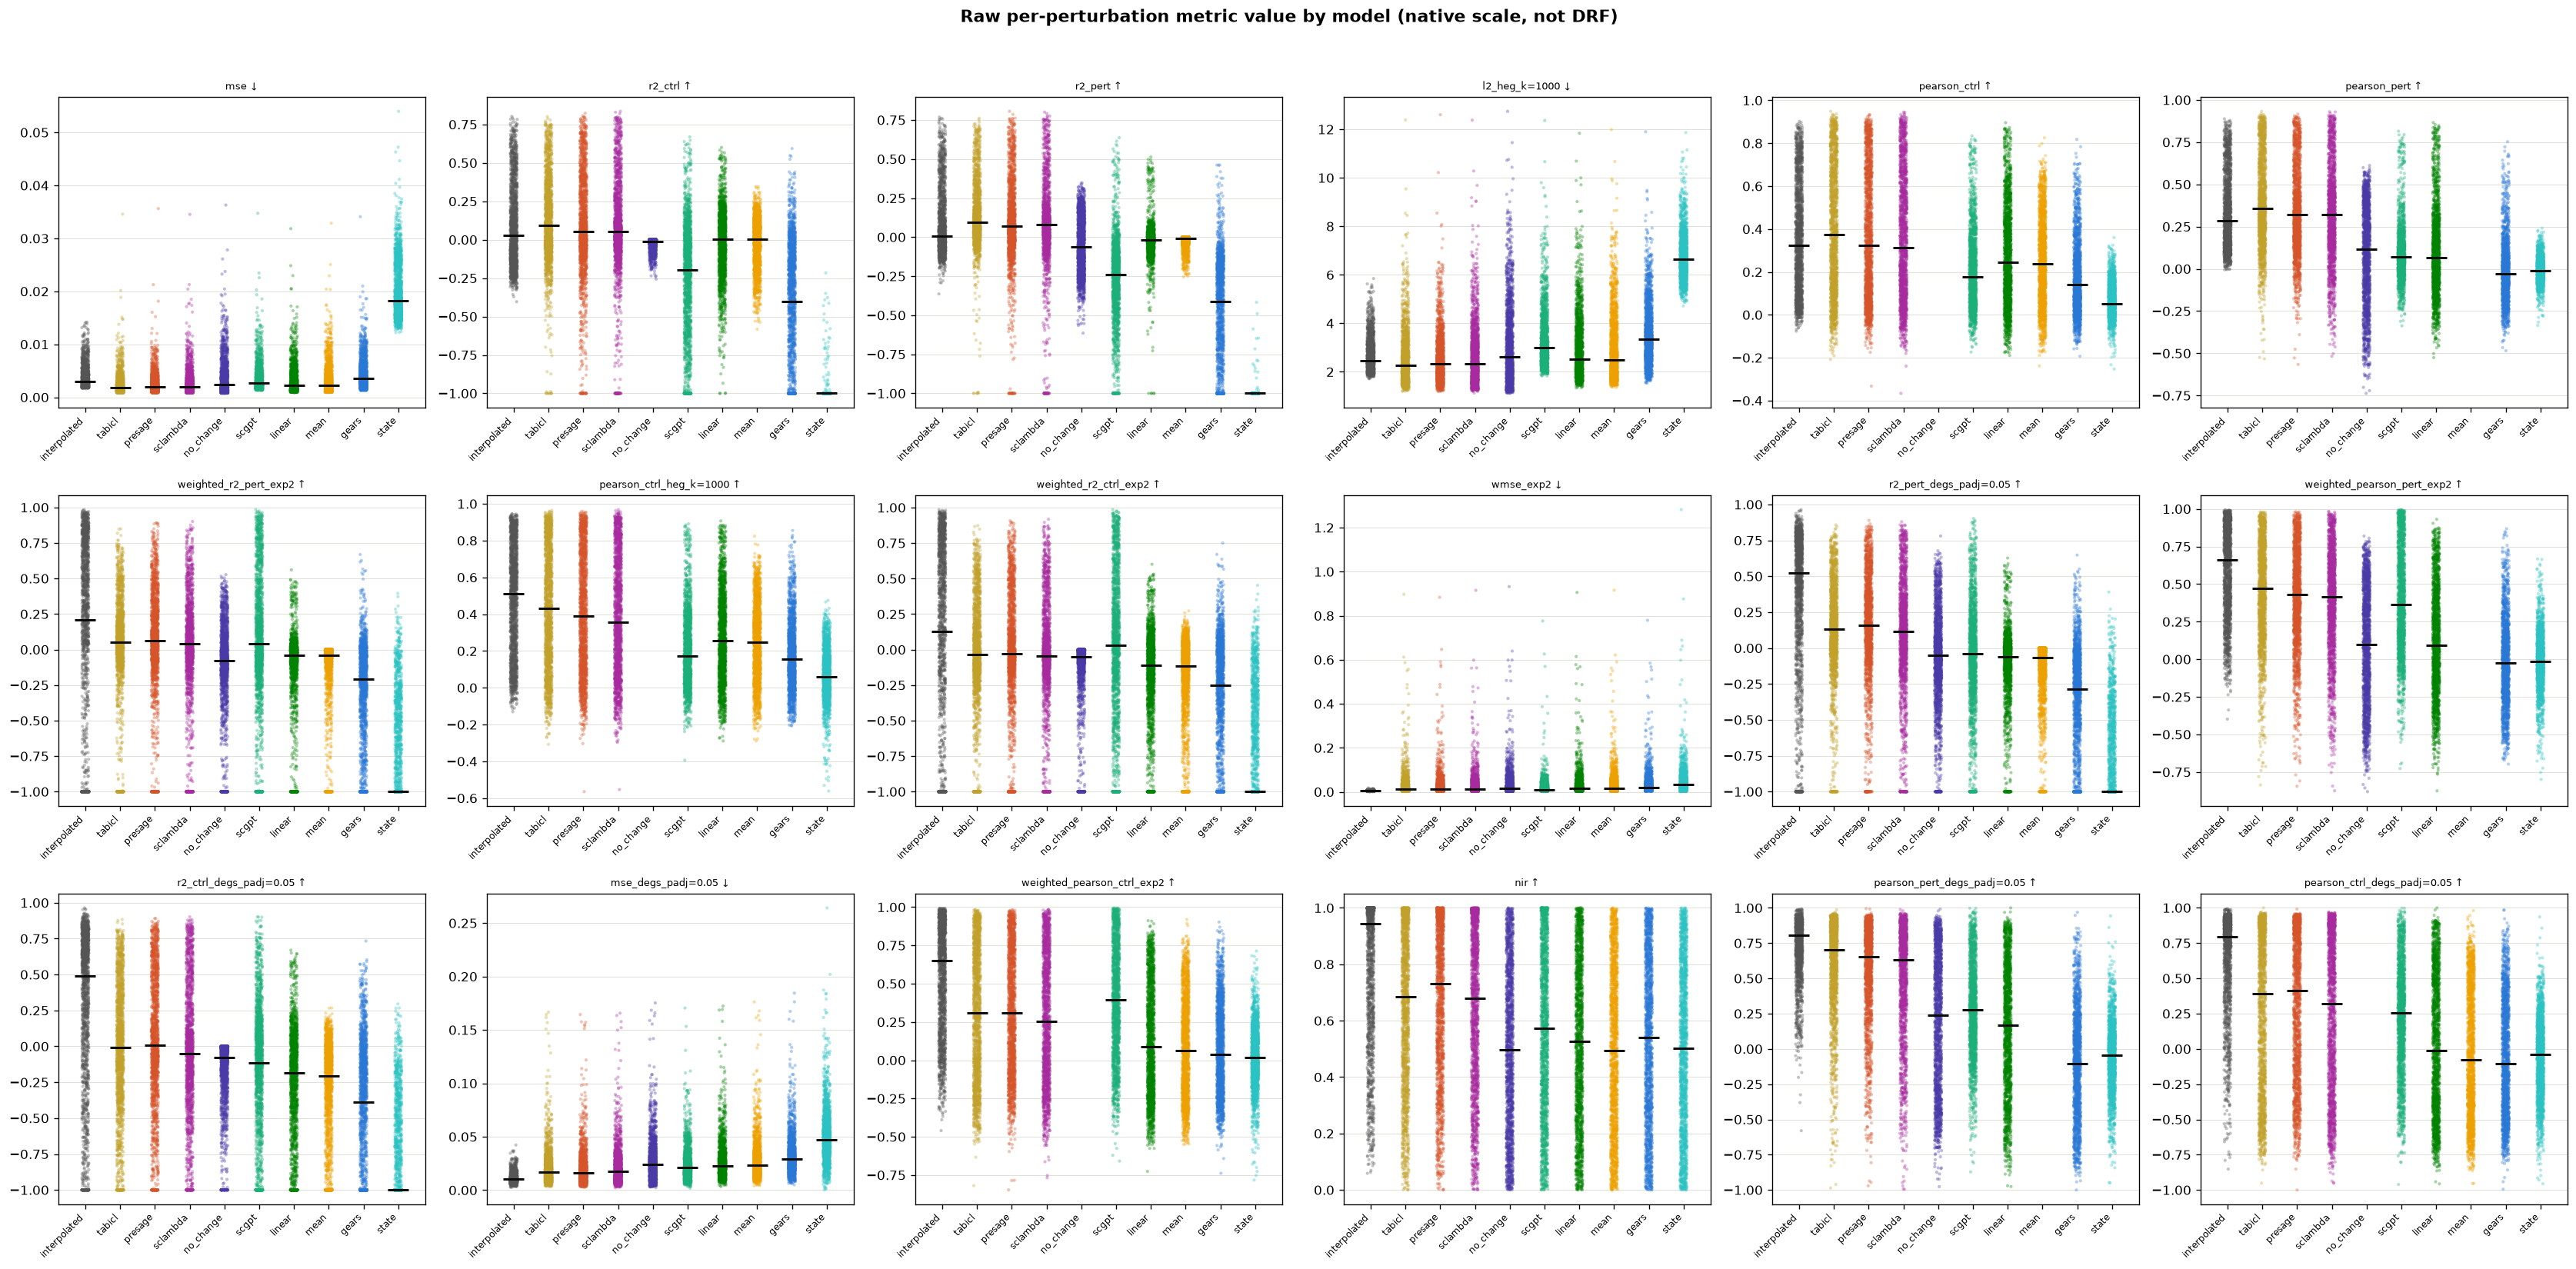

In [22]:
plot_stripplot(scores)

**Interpretations:**

Protocols are arranged by order of median DRF, from lowest to highest, left to right, top to bottom. We observe:

1. While some protocols lead to similar outputs, we can still observe a large variety of stripplots already displaying how different protocols can lead to very conflicting conclusions.
2. Stripplots alone are difficult to analyze thoroughly as each protocol outputs a different dynamic range of values.
3. We notice that for poorly calibrated protocols (the ones at the top), the *oracle* `interpolated` baseline is performing sometimes even worse than certain models. This may be a simple artifact of the fact that `interpolated` is scored from a noisier estimate than any other model. But it also shows that even a supposedly strong baseline can perform badly on poorly calibrated metrics, which therefore should not be trusted.
4. Quite strikingly, across models and baselines and even for the *oracle* `interpolated`, certain perturbations lead to poor scoring across protocols. Without further investigation, a plausible explanation might be their low effect strength/size, hence the inability of any model to predict the perturbation outcome precisely. The problem with low effect strength/size perturbations is that it is difficult to determine whether this is actual biology, or poor efficiency of the knock-out, or low cell count.

Let's move on to the SBB normalization to gain further interpretability.

## 3. SBB Normalization

To compare protocols living on wildly different native scales ($\text{Pearson r} \in [-1,1]$, $\mathrm{MSE} \in [0,∞)$, $\mathrm{NIR} \in [0,1]$, ...) on equal footing, we calibrate every raw score against its own protocol's positive and negative baselines, following {cite:t}`Vollenweider_2026`, eq. 17.

For a raw score $\hat{s}^{(a)}$, with $s^{(a)}_\mathrm{pos}/s^{(a)}_\mathrm{neg}$ the same metric evaluated against the positive/negative baseline instead of the prediction:

$$
\hat s_{\mathrm{cal}}^{(a)} = \max\left(0,\ \frac{\hat{s}^{(a)} - s^{(a)}_\mathrm{pos}}{s^{(a)}_\mathrm{neg} - s^{(a)}_\mathrm{pos}}\right)
$$

$s^{(a)}_\mathrm{pos}$ here is the raw held-out technical duplicate ({cite:t}`Vollenweider_2026`'s own definition, `tech_dup_mean` above), not DRF's DE-weighted interpolated duplicate: BDS and this SBB score share that same raw bound. The distinction matters: 0 is supposed to mean "as good as it gets given technical noise," but the interpolated duplicate can sit closer to the negative baseline than that for weak-effect perturbations (it shrinks that way by design), which would make a near-0 SBB or a BDS win mean nothing more than "about as good as a shrinkage-toward-the-mean predictor".

This is direction-agnostic: the same expression applies whether the raw metric is "higher is better" or "lower is better", since $s^{(a)}_\mathrm{pos}$/$s^{(a)}_\mathrm{neg}$ already encode which end is which and reads as: how much of the room between the best achievable score and an uninformative guess does the prediction still occupy? 0 = matches the technical duplicate, 1 = no better than the negative baseline, and uncapped values above 1 mean worse than an uninformative guess (clipped only from below, at 0, for predictions that nominally beat the duplicate).

This is only meaningful when $s^{(a)}_\mathrm{pos}$ and $s^{(a)}_\mathrm{neg}$ actually land on the correct sides of each other for a given perturbation. Otherwise there's no real room to place the prediction in, and blindly computing the ratio anyway silently rewards whichever model happens to sit furthest from the positive control (the sign flip floors it to 0, "best," for exactly the wrong reason). Perturbations that fail this are excluded below (`_sbb_calibrated_per_pert`/`per_pert_sbb` return NaN and drop them), which is exactly what BDS measures per protocol: the SBB heatmap further down annotates each row with that same BDS fraction, so a row's comparison can be read alongside how much of the perturbation set it's actually based on.

Before doing anything, we need to **correct the native bounds** for the later SBB calibration:

`native_bounds`'s negative was computed against `gt_half` only because `sp.calibrate()` applies one
shared truth to both pos and neg in a single run. Unlike `positive` (which is the `technical duplicate`, so built from this perturbation's own held-out half, scoring it against gt_all_cells would leak into the cells it's built from), the `negative` baseline (all_perturbed_mean/control_mean) never touches this perturbation's own cells, so it can safely reuse the `gt_all_cells` score already computed for it as a "model" above.

In [ ]:
NEGATIVE_MODEL = {None: "mean", "global_mean": "mean", "control_mean": "no_change"}
for p in protocols:
    neg_scores = scores[NEGATIVE_MODEL[p.default_negative]][p.name]
    for pert, bounds in native_bounds[p.name].items():
        if pert in neg_scores:
            bounds["negative"] = neg_scores[pert]

In [ ]:
def _sbb_calibrated_per_pert(scores, better):
    """SBB calibration (Vollenweider & Bühlmann 2026)"""
    pos, neg, pred = scores["positive"], scores["negative"], scores["prediction"]
    wins = pos < neg if better == "lower" else pos > neg
    if not wins:
        return float("nan")
    return max(
        0.0, float((pred - pos) / (neg - pos))
    )  # We can add the + \xi = + 1e-6, but then the perturb mean no longer calibrate to 1.


def per_pert_sbb(
    model_name: str,
    scores: dict[str, dict[str, dict[str, float]]],
    native_bounds: dict[str, dict[str, dict[str, float]]],
    protocols,
) -> dict[str, dict[str, float]]:
    """Per-protocol, per-perturbation SBB-calibrated score for one model against the protocol's own native bounds"""
    out = {}
    for p in protocols:
        m_scores, bounds = scores[model_name][p.name], native_bounds[p.name]
        sbb = {}
        for pert in sorted(set(m_scores) & set(bounds)):
            pred, pos, neg = m_scores[pert], bounds[pert]["positive"], bounds[pert]["negative"]
            if not (np.isfinite(pred) and np.isfinite(pos) and np.isfinite(neg)):
                continue
            value = _sbb_calibrated_per_pert({"positive": pos, "negative": neg, "prediction": pred}, p.better)
            if np.isfinite(value):
                sbb[pert] = value
        out[p.name] = sbb
    return out


# One row per (model, protocol, perturbation) -- kept long-form, like gene_counts/per_pert_calib
# above, so the heatmap below can let pandas/seaborn compute the median/P25/P75 directly.
sbb_rows = [
    {"model": model, "protocol": protocol, "perturbation": pert, "value": val}
    for model in PREDICTION_DIRS
    for protocol, vals in per_pert_sbb(model, scores, native_bounds, protocols).items()
    for pert, val in vals.items()
]
sbb_per_pert = pd.DataFrame(sbb_rows)

# Computed once, reused by the SBB heatmap's column order below and by the SBB view in the
# statistical-tests section further down.
avg_ranks_sbb = compute_avg_ranks(sbb_per_pert, protocols)

In [25]:
def plot_sbb_heatmap(sbb_per_pert: pd.DataFrame) -> None:
    """Model x protocol SBB heatmap: median [P25, P75] over perturbations"""
    model_order = avg_ranks_sbb.mean(axis=1).sort_values().index
    stat = sbb_per_pert.groupby(["protocol", "model"])["value"].agg(
        median="median", p25=lambda s: np.percentile(s, 25), p75=lambda s: np.percentile(s, 75)
    )
    med = stat["median"].unstack("model").reindex(index=protocol_order, columns=model_order)
    p25 = stat["p25"].unstack("model").reindex(index=protocol_order, columns=model_order)
    p75 = stat["p75"].unstack("model").reindex(index=protocol_order, columns=model_order)

    bds_frac = calib[calib["calibrator"] == "bds"].set_index("protocol")["bds"]
    row_labels = [f"{p}  (BDS={bds_frac.get(p, float('nan')):.2f})" for p in protocol_order]

    fig, ax = plt.subplots(figsize=(13, 14))
    sns.heatmap(
        med,
        mask=med.isna(),
        annot=False,
        cmap="RdYlGn_r",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "median SBB (0 = best, ≥1 = no better than negative baseline)"},
        ax=ax,
    )
    for i, protocol in enumerate(protocol_order):
        for j, model in enumerate(model_order):
            if pd.isna(med.loc[protocol, model]):
                continue
            ax.text(j + 0.5, i + 0.38, f"{med.loc[protocol, model]:.2f}", ha="center", va="center", fontsize=9)
            ax.text(
                j + 0.5,
                i + 0.68,
                f"[{p25.loc[protocol, model]:.2f}, {p75.loc[protocol, model]:.2f}]",
                ha="center",
                va="center",
                fontsize=6.5,
            )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(model_order, rotation=30, ha="right")
    ax.set_yticklabels(row_labels, rotation=0)
    ax.set_title(
        "Model-comparison SBB vs. each protocol's own baseline\n"
        "median [P25, P75] over perturbations where the protocol's own BDS check passes",
        fontsize=11,
        fontweight="bold",
    )
    fig.tight_layout()

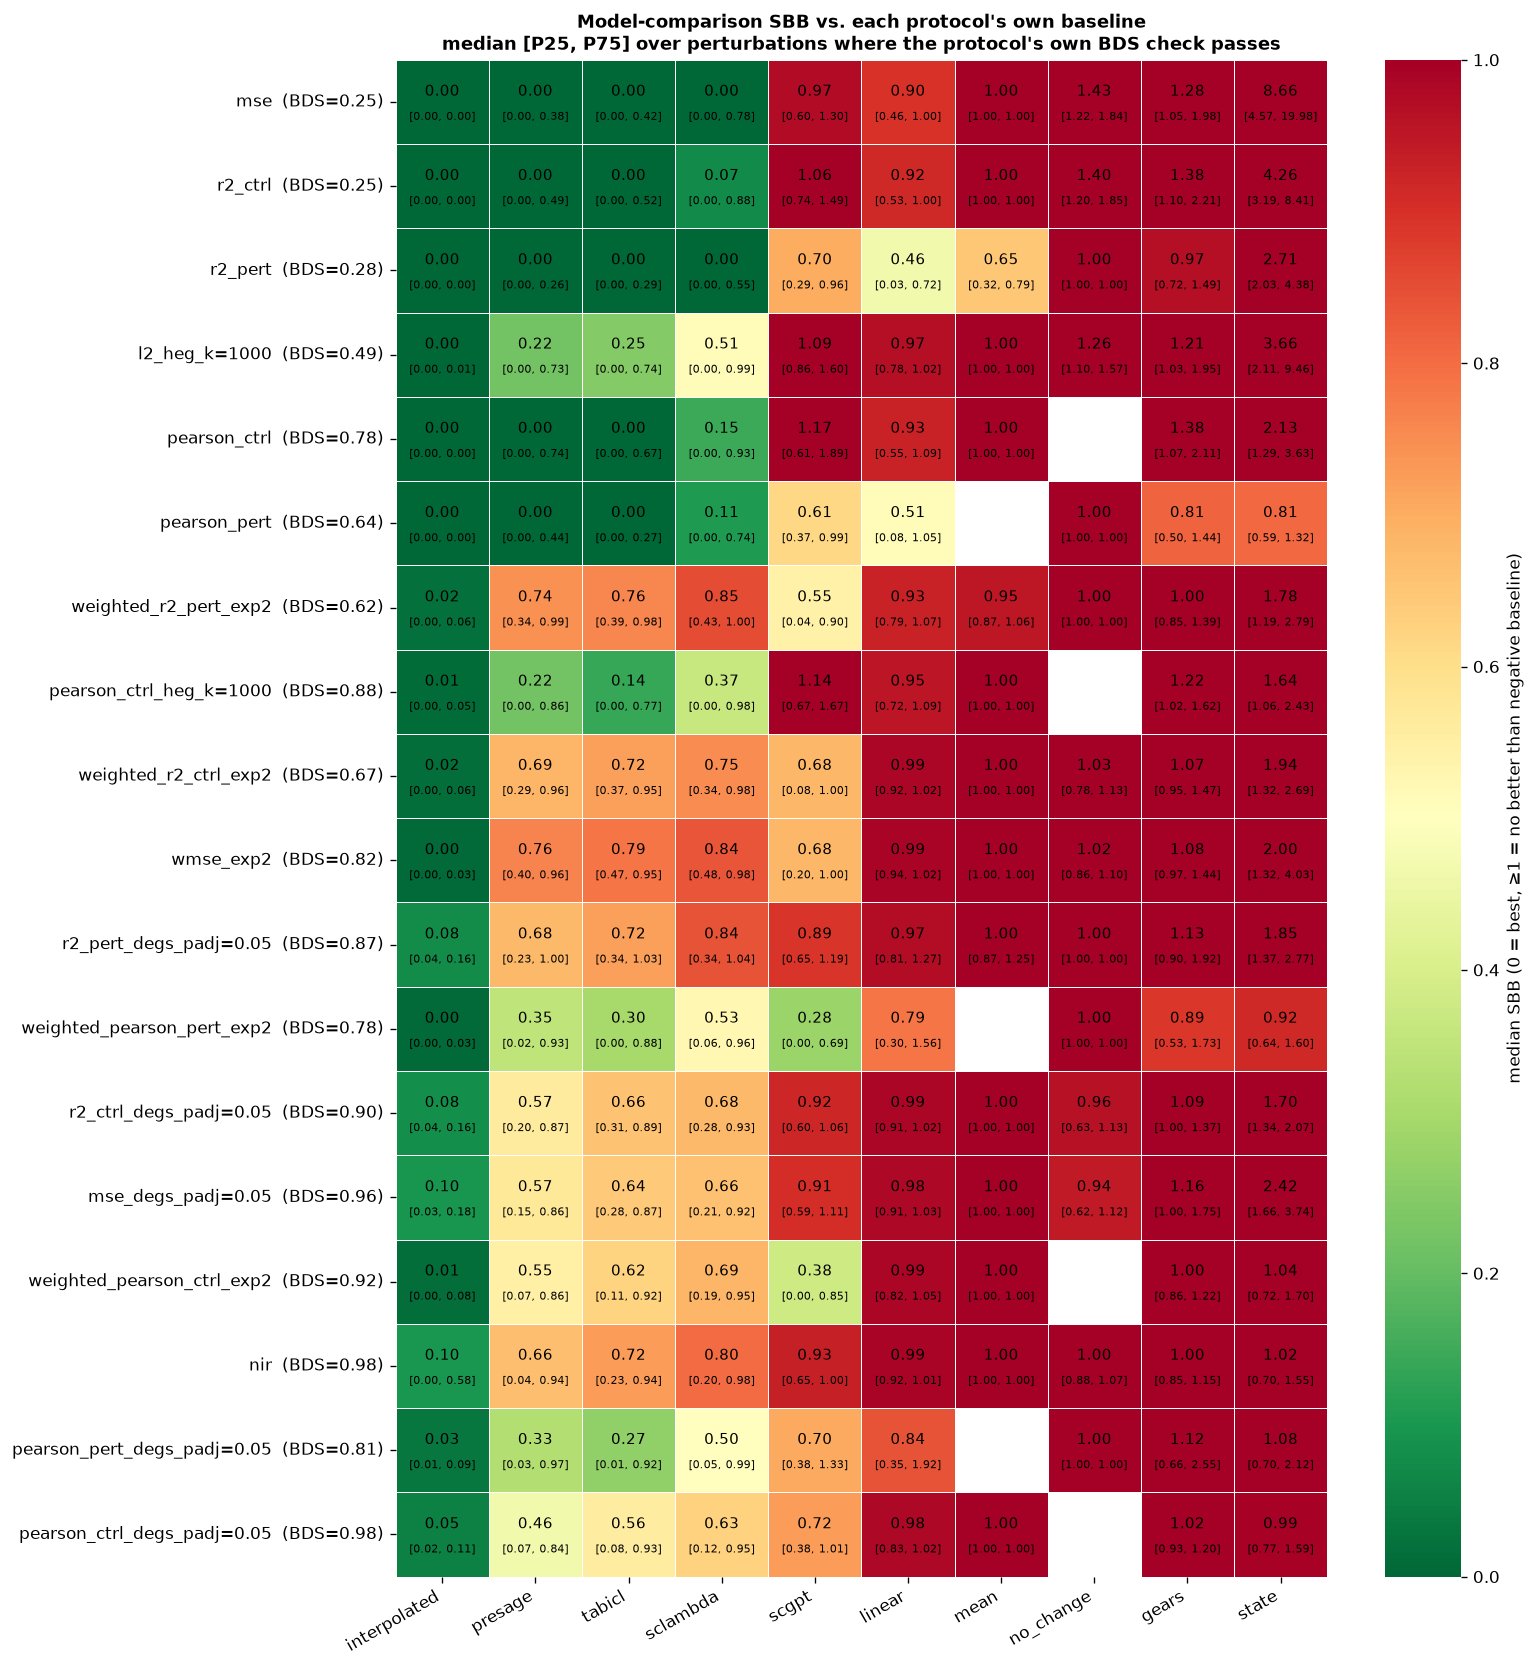

In [26]:
plot_sbb_heatmap(sbb_per_pert)

**Interpretation:**

On this heatmap, the greener, the better. We can have a look at the rows `l2_heg_k=1000` and `pearson_ctrl_heg_k=1000` and the columns `scgpt`, `gears`, `linear` and `mean` which is a setting similar to {cite:t}`AhlmannEltze_2025`.

In this scenario, we can indeed conclude similarly to {cite:t}`AhlmannEltze_2025`, where deep-learning models fail to beat simple linear baselines. However, looking at better calibrated metrics like in the bottom rows, this conclusion flips and deep-learning models do end up beating those baselines, concluding similarly to {cite:t}`Miller_2025`.

Interestingly, `scgpt` is doing a great job on any weighted metrics and does much worse on its $\text{DEG}$ counterpart. As we explored earlier in [section 1.E.i](#i-mse-vs-pearson-vs-r2-per-gene-decomposition-of-the-drf), weighted metrics concentrate all of the signal on very few top genes. The fact that `scgpt` does very well here and its performance drops dramatically when using the $\text{DEG}$ metrics (which indeed has a higher effective gene number $N^\text{eff}$, but remains on a similar order of magnitude) indicates it is doing a great job only on those top genes. In fact, it could be the case that `scgpt` only manages to predict correctly the perturbed gene, plausibly because scGPT's input encoding tells it explicitly which gene was perturbed, and it's learned the near-mechanical shortcut "set that gene's own expression near zero" rather than genuinely inferring the downstream regulatory response.

> [!TIP]
> Therefore, this is a new argument for using weighted metrics alongside their un-weighted DEG counter art, because it allows flagging for such undesirable behavior.

> [!WARNING]
> The heatmap here is restricted to perturbations passing the $\text{BDS}$ threshold, so it doesn't display a full picture like with the raw score: it restricts the interpretation to perturbations which can indeed be separated from the negative baseline under the given protocol of evaluation. Therefore, the $\text{SBB}$ calibration is a powerful tool to compare protocols, but it is important to keep the $\text{BDS}$ fraction for consistency.
>
> Overall, we believe that the more perturbations originally kept, the better, because one cannot be sure beforehand whether a new perturbation will be separable from the negative baseline, so it is fairer to assess model performance on as much data as possible. Hence, performance should rather be assessed on the raw score, and $\text{SBB}$ calibration might be kept solely for the purpose of rescaling protocols so they can be compared them against each other.

Before analyzing further, let's have a look at the actual rank of each model and whether their rank is statistically significant.

## 4. Statistical Tests

We test model differences on two views, side by side: the raw score and the $\text{SBB}$-calibrated score from above for completeness. However, as pointed out earlier, the $\text{SBB}$ rank might look over-optimistic as it filters out perturbations that don't pass the $\text{BDS}$ threshold. 

We show each model's average rank under both schemes. We then compute significance. To do so, we suggest two different approaches:

- **Wilcoxon**
  To identify which model is the best, one can plot a Critical Difference (CD) diagram, which ranks models based on their performance and tests for significant differences. {cite:t}`Demsar_2026` recommend doing so using two non-parametric tests: a Friedman test, to test for any significant difference at all, and second, a Nemenyi post-hoc test to compare model pairs. However, {cite:t}`Benavoli_2025` argue the Nemenyi test results in pairs of model differences which are not independent of the other suite of models being tested, which is therefore undesirable. Alternatively, they suggest Wilcoxon signed-rank tests directly on paired per-perturbation differences corrected with Holm's step-down procedure.

- **Bayes Factor**
  A complementary robustness check: instead of asking whether an observed gap is distinguishable from noise, it asks how often the observed ranking between two models would hold up if the benchmark's perturbations were resampled. This follows the usual convention of the DREAM Challenge leaderboard {cite:t}`Dream_2019` for checking for robustness.

  $$K_\text{model1, model2} = \frac{\sum_{i=1}^{1000} pm_{model1, i} < pm_{model2, i}}{\sum_{i=1}^{1000} pm_{model1, i} \geq pm_{model2, i}}$$

  The $\text{Bayes Factor}$ is computed as follows: 
  
  - Given the perturbation index $a$, perturbation set $\mathcal{A}$, the predicted score $\hat{s}^{(a)}$ for a certain protocol (this score being SBB calibrated or not), $b\in \{1,...,N_b\}$ bootstrap $\mathcal{B}_b$ drawn with replacement of the perturbation set so that $\mathcal{B}_b \subset \mathcal{A}$

  We define the model primary score as: 

  $$
  \tilde s_{\text{model}}^{(b)} = \operatorname{median}_{a \in \mathcal{B}_b} \hat{s}^{(a)}_{\text{model}}, \qquad b \in \{1,...,N_b\}
  $$

  Note that one can choose whichever pooling strategy (even some perturbation weighting scheme) that makes the most sense for their benchmark to aggregate scores across perturbations. We recommend the median for its resilience to extreme values, where certain perturbations can be very poorly predicted with some models and might therefore skew their whole performance, giving a pessimistic view of their capability.

  We note: 

  $$
  p_{\text{model}_1 \succ \text{model}_2} = \frac{1}{N_b}\sum_{b=1}^{N_b} \mathbb{I}\left[\tilde s_{\text{model}_1}^{(b)} < \tilde s_{\text{model}_2}^{(b)}\right]
  $$

  And the $\text{Bayes Factor}$ is:

  $$
  \text{Bayes Factor}_{\text{model}_1,\text{model}_2} = \frac{p_{\text{model}_1 \succ \text{model}_2}}{1 - p_{\text{model}_1 \succ \text{model}_2}}
  $$

  > [!IMPORTANT]
  > In {cite}`Dream_2019`, only the best model is compared against every other model. Therefore, if $\tilde s_{\text{model}_1}^{(b)} = \tilde s_{\text{model}_2}^{(b)}$, then this is to the disadvantage of the overall best model. Also, in case of a non-significant $\text{Bayes Factor}$, they apply a *tie-breaking metric*, to finally pick a winner. We choose to be simpler and want to check if one model beating the other is significant. Therefore, we choose that in case of a tie $\tilde s_{\text{model}_1}^{(b)} = \tilde s_{\text{model}_2}^{(b)}$, we randomly assign the win. One may choose differently.

  In {cite:t}`Dream_2019`, a $\text{Bayes Factor} > 5$ is thought to be significant. For a $p_{\text{model}_1 \succ \text{model}_2} > 0.95$, it would actually need a $\text{Bayes Factor} > 19$. As in the DREAM challenge, we use $N_b = 1000$.

  > [!NOTE]
  > for our use case, only the $p_{\text{model}_1 \succ \text{model}_2}$ is really being used, and we also apply Holm's correction. 

In [ ]:
from itertools import combinations

from scipy import stats
from statsmodels.stats.multitest import multipletests

In [28]:
def pairwise_wilcoxon_holm(score_per_pert: pd.DataFrame, protocols, models: list[str]) -> pd.DataFrame:
    """Two-sided Wilcoxon signed-rank test on paired per-perturbation score gaps, for every model pair, Holm-corrected within each protocol."""
    rows = []
    for p in tqdm(protocols, desc="wilcoxon", leave=False, ncols=80):
        wide = score_per_pert.loc[score_per_pert["protocol"] == p.name].pivot(
            index="perturbation", columns="model", values="value"
        )
        pair_rows = []
        for model_a, model_b in combinations(models, 2):
            if model_a not in wide or model_b not in wide:
                continue
            diffs = (wide[model_a] - wide[model_b]).dropna().to_numpy()
            if diffs.size < 1 or np.all(diffs == 0):
                statistic, pvalue = float("nan"), float("nan")
            else:
                statistic, pvalue = stats.wilcoxon(diffs, alternative="two-sided")
            pair_rows.append(
                {
                    "protocol": p.name,
                    "model_a": model_a,
                    "model_b": model_b,
                    "n": int(diffs.size),
                    "statistic": float(statistic),
                    "pvalue": float(pvalue),
                }
            )
        pvals = np.array([r["pvalue"] for r in pair_rows])
        finite = np.isfinite(pvals)
        holm = np.full(pvals.shape, np.nan)
        if finite.sum() > 0:
            holm[finite] = multipletests(pvals[finite], method="holm")[1]
        for r, h in zip(pair_rows, holm, strict=True):
            r["pvalue_holm"] = float(h)
        rows.extend(pair_rows)
    return pd.DataFrame(rows)

In [ ]:
def pairwise_bayes_factor(
    score_per_pert: pd.DataFrame, protocols, models: list[str], n_resamples: int = 1000, seed: int = 42
) -> pd.DataFrame:
    """Bootstrap "Bayes Factor" for every model pair, on paired per-perturbation score values.

    For each protocol and unordered pair, resamples the perturbations they share with
    replacement, recomputes each model's resampled median score, and tallies how often
    model_a's median is lower (under the assumption lower is better).

    ``bf_ab = p_a_wins / (1 - p_a_wins)`` is the odds A beats B;

    Also returns a Holm-corrected two-sided bootstrap p-value per pair (``pvalue_boot``/
    ``pvalue_boot_holm``): ``2 * min(p_a_wins, 1 - p_a_wins)`` is the standard percentile-
    bootstrap two-sided p-value, Holm-corrected across the ``C(len(models), 2)`` pairs within
    each protocol -- the same footing as :func:`pairwise_wilcoxon_holm`'s ``pvalue_holm``.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for p in tqdm(protocols, desc="bootstrap BF", leave=False, ncols=80):
        wide = score_per_pert.loc[score_per_pert["protocol"] == p.name].pivot(
            index="perturbation", columns="model", values="value"
        )
        for model_a, model_b in combinations(models, 2):
            if model_a not in wide or model_b not in wide:
                continue
            paired = wide[[model_a, model_b]].dropna()
            n = len(paired)
            if n < 1:
                p_a_wins = float("nan")
            else:
                idx = rng.integers(0, n, size=(n_resamples, n))
                a_vals, b_vals = paired[model_a].to_numpy(), paired[model_b].to_numpy()
                pm_a, pm_b = np.median(a_vals[idx], axis=1), np.median(b_vals[idx], axis=1)
                a_wins = pm_a < pm_b
                tied = pm_a == pm_b
                a_wins[tied] = rng.random(tied.sum()) < 0.5
                p_a_wins = float(a_wins.mean())
            rows.append({"protocol": p.name, "model_a": model_a, "model_b": model_b, "n": n, "p_a_wins": p_a_wins})

    df = pd.DataFrame(rows)
    p_a_wins = df["p_a_wins"].to_numpy()
    p_b_wins = 1.0 - p_a_wins
    df["bf_ab"] = np.divide(p_a_wins, p_b_wins, out=np.full_like(p_a_wins, np.inf), where=p_b_wins != 0)
    df["pvalue_boot"] = np.minimum(p_a_wins, p_b_wins) * 2  # always <= 1 for p in [0, 1], no clip needed

    df["pvalue_boot_holm"] = np.nan
    for p in protocols:
        mask = df["protocol"] == p.name
        pvals = df.loc[mask, "pvalue_boot"].to_numpy() # type: ignore
        finite = np.isfinite(pvals)
        holm = np.full(pvals.shape, np.nan)
        if finite.sum() > 0:
            holm[finite] = multipletests(pvals[finite], method="holm")[1] # type: ignore
        df.loc[mask, "pvalue_boot_holm"] = holm
    return df

In [40]:
alpha = 0.05
views_wilcoxon = {}
for quantity, per_pert, ranks in tqdm(
    [("raw score", raw_per_pert, avg_ranks_raw), ("SBB", sbb_per_pert, avg_ranks_sbb)], desc="views", ncols=80
):
    pairwise = pairwise_wilcoxon_holm(per_pert, protocols, MODELS)
    pairwise["significant"] = np.isfinite(pairwise["pvalue_holm"]) & (pairwise["pvalue_holm"] < alpha)
    views_wilcoxon[quantity] = (pairwise, ranks)

views_bf = {}
for quantity, per_pert, ranks in tqdm(
    [("raw score", raw_per_pert, avg_ranks_raw), ("SBB", sbb_per_pert, avg_ranks_sbb)], desc="views", ncols=80
):
    bf = pairwise_bayes_factor(per_pert, protocols, MODELS)
    bf["significant"] = np.isfinite(bf["pvalue_boot_holm"]) & (bf["pvalue_boot_holm"] < alpha)
    views_bf[quantity] = (bf, ranks)

views: 100%|██████████████████████████████████████| 2/2 [01:06<00:00, 33.15s/it]


In [ ]:
def _pack_levels(cliques: list[list[str]], x: dict[str, float]) -> list[tuple[list[str], int]]:
    """Assign each clique to the lowest level whose span it doesn't touch or overlap.

    Two cliques that only *touch* at a shared rank position (e.g. spans ending/starting at the
    same x) still conflict and must go on different levels -- otherwise they'd render as one
    unbroken line and misread as a single, larger (transitively) non-significant group, which
    is exactly the false impression a chain of pairwise-only non-significant results can give.
    Plain greedy interval-graph coloring, sorted by start position.
    """
    spans = sorted(cliques, key=lambda g: x[g[0]])
    level_ends: list[float] = []
    placed = []
    for g in spans:
        start, end = x[g[0]], x[g[-1]]
        level = next((lv for lv, e in enumerate(level_ends) if start > e), None)
        if level is None:
            level = len(level_ends)
            level_ends.append(end)
        else:
            level_ends[level] = end
        placed.append((g, level))
    return placed


def _maximal_nonsignificant_cliques(order: list[str], significant: set[frozenset]) -> list[list[str]]:
    """Maximal contiguous (in ``order``) groups where every internal pair is non-significant.

    Only contiguous ranges matter here -- the diagram places models by rank on a line, and a
    connecting bar only makes visual sense over a contiguous span of that line, exactly how a
    critical-difference diagram's bars work.
    """
    n = len(order)
    candidates = []
    for i in range(n):
        for j in range(i + 1, n):
            group = order[i : j + 1]
            pairs_ok = all(
                frozenset((group[a], group[b])) not in significant
                for a in range(len(group))
                for b in range(a + 1, len(group))
            )
            if pairs_ok:
                candidates.append(group)
    return [g for g in candidates if not any(set(g) < set(other) for other in candidates)]


def _declutter_y(xs: list[tuple[str, float]], radius: float) -> dict[str, float]:
    """Greedy 1D beeswarm: push each point down only as far as needed to clear collision

    (Euclidean, in data units) with already-placed points -- x never moves (it's the real
    plotted quantity), and the y-offset scales with how much overlap actually needs
    resolving, instead of a fixed step applied uniformly to anything in the same bucket.
    """
    placed: list[tuple[float, float]] = []
    result: dict[str, float] = {}
    step = radius * 0.85  # slight intentional overlap so markers "kiss" rather than gap
    for model, x in xs:  # xs pre-sorted by x (ascending rank) -- reuses `order`
        y = 0.0
        while any((x - px) ** 2 + (y - py) ** 2 < radius**2 for px, py in placed):
            y -= step
        placed.append((x, y))
        result[model] = y
    return result


def plot_significance_cliques(views: dict[str, tuple[pd.DataFrame, pd.DataFrame]], title: str) -> None:
    """Which models are NOT distinguishable from each other, per protocol, one column per score type."""
    # protocol_order: the shared global (DRF median, ascending) -- same rows as every other
    # model-comparison figure in this notebook.
    quantities = list(views)
    min_bar_width = 0.15
    fig, axes = plt.subplots(
        len(protocol_order), len(quantities), figsize=(7 * len(quantities), len(protocol_order) * 0.7), sharex="col"
    )
    axes = np.asarray(axes).reshape(len(protocol_order), len(quantities))
    for col, quantity in enumerate(quantities):
        pairwise, ranks = views[quantity]
        for row_i, protocol in enumerate(protocol_order):
            ax = axes[row_i, col]
            row = ranks[protocol].dropna()
            order = row.sort_values().index.tolist()
            sub = pairwise[pairwise["protocol"] == protocol]
            significant = {
                frozenset((r.model_a, r.model_b))
                for r in sub.itertuples()
                if r.model_a in order and r.model_b in order and r.significant
            }
            y_offsets = _declutter_y([(m, row[m]) for m in order], radius=0.15)
            for model in order:
                ax.scatter(
                    row[model], y_offsets[model], color=COLORS[model], s=45, zorder=3, edgecolor="white", linewidth=1
                )
            cliques = _maximal_nonsignificant_cliques(order, significant)
            packed = _pack_levels(cliques, row.to_dict())
            for group, level in packed:
                y = 0.3 + level * 0.4
                x0, x1 = row[group[0]], row[group[-1]]
                if x1 - x0 < min_bar_width:
                    cx = (x0 + x1) / 2
                    x0, x1 = cx - min_bar_width / 2, cx + min_bar_width / 2
                ax.plot([x0, x1], [y, y], color="#52514e", linewidth=2, solid_capstyle="butt", zorder=2)
                ax.plot([x0, x0], [y - 0.08, y + 0.08], color="#52514e", linewidth=2, zorder=2)
                ax.plot([x1, x1], [y - 0.08, y + 0.08], color="#52514e", linewidth=2, zorder=2)
            ax.set_yticks([0])
            ax.set_yticklabels([protocol] if col == 0 else [], fontsize=7)
            min_y = min(y_offsets.values(), default=0.0)
            max_level = max((level for _, level in packed), default=-1)
            top_y = 0.3 + (max_level + 1) * 0.4 if max_level >= 0 else 0.6
            ax.set_ylim(min_y - 0.2, max(top_y, 1.2))
            ax.tick_params(axis="y", length=0)
            for spine in ("top", "right", "left"):
                ax.spines[spine].set_visible(False)
            ax.grid(axis="x", color="#e1e0d9", linewidth=0.6)
            ax.set_axisbelow(True)
        axes[0, col].set_title(quantity, fontsize=10, fontweight="bold")
        axes[-1, col].set_xlim(0.5, len(MODELS) + 0.5)
        axes[-1, col].set_xticks(range(1, len(MODELS) + 1))
        axes[-1, col].set_xlabel("average rank (1 = best)")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[m], markersize=8, label=m) # type: ignore
        for m in MODELS
    ]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.0)
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))

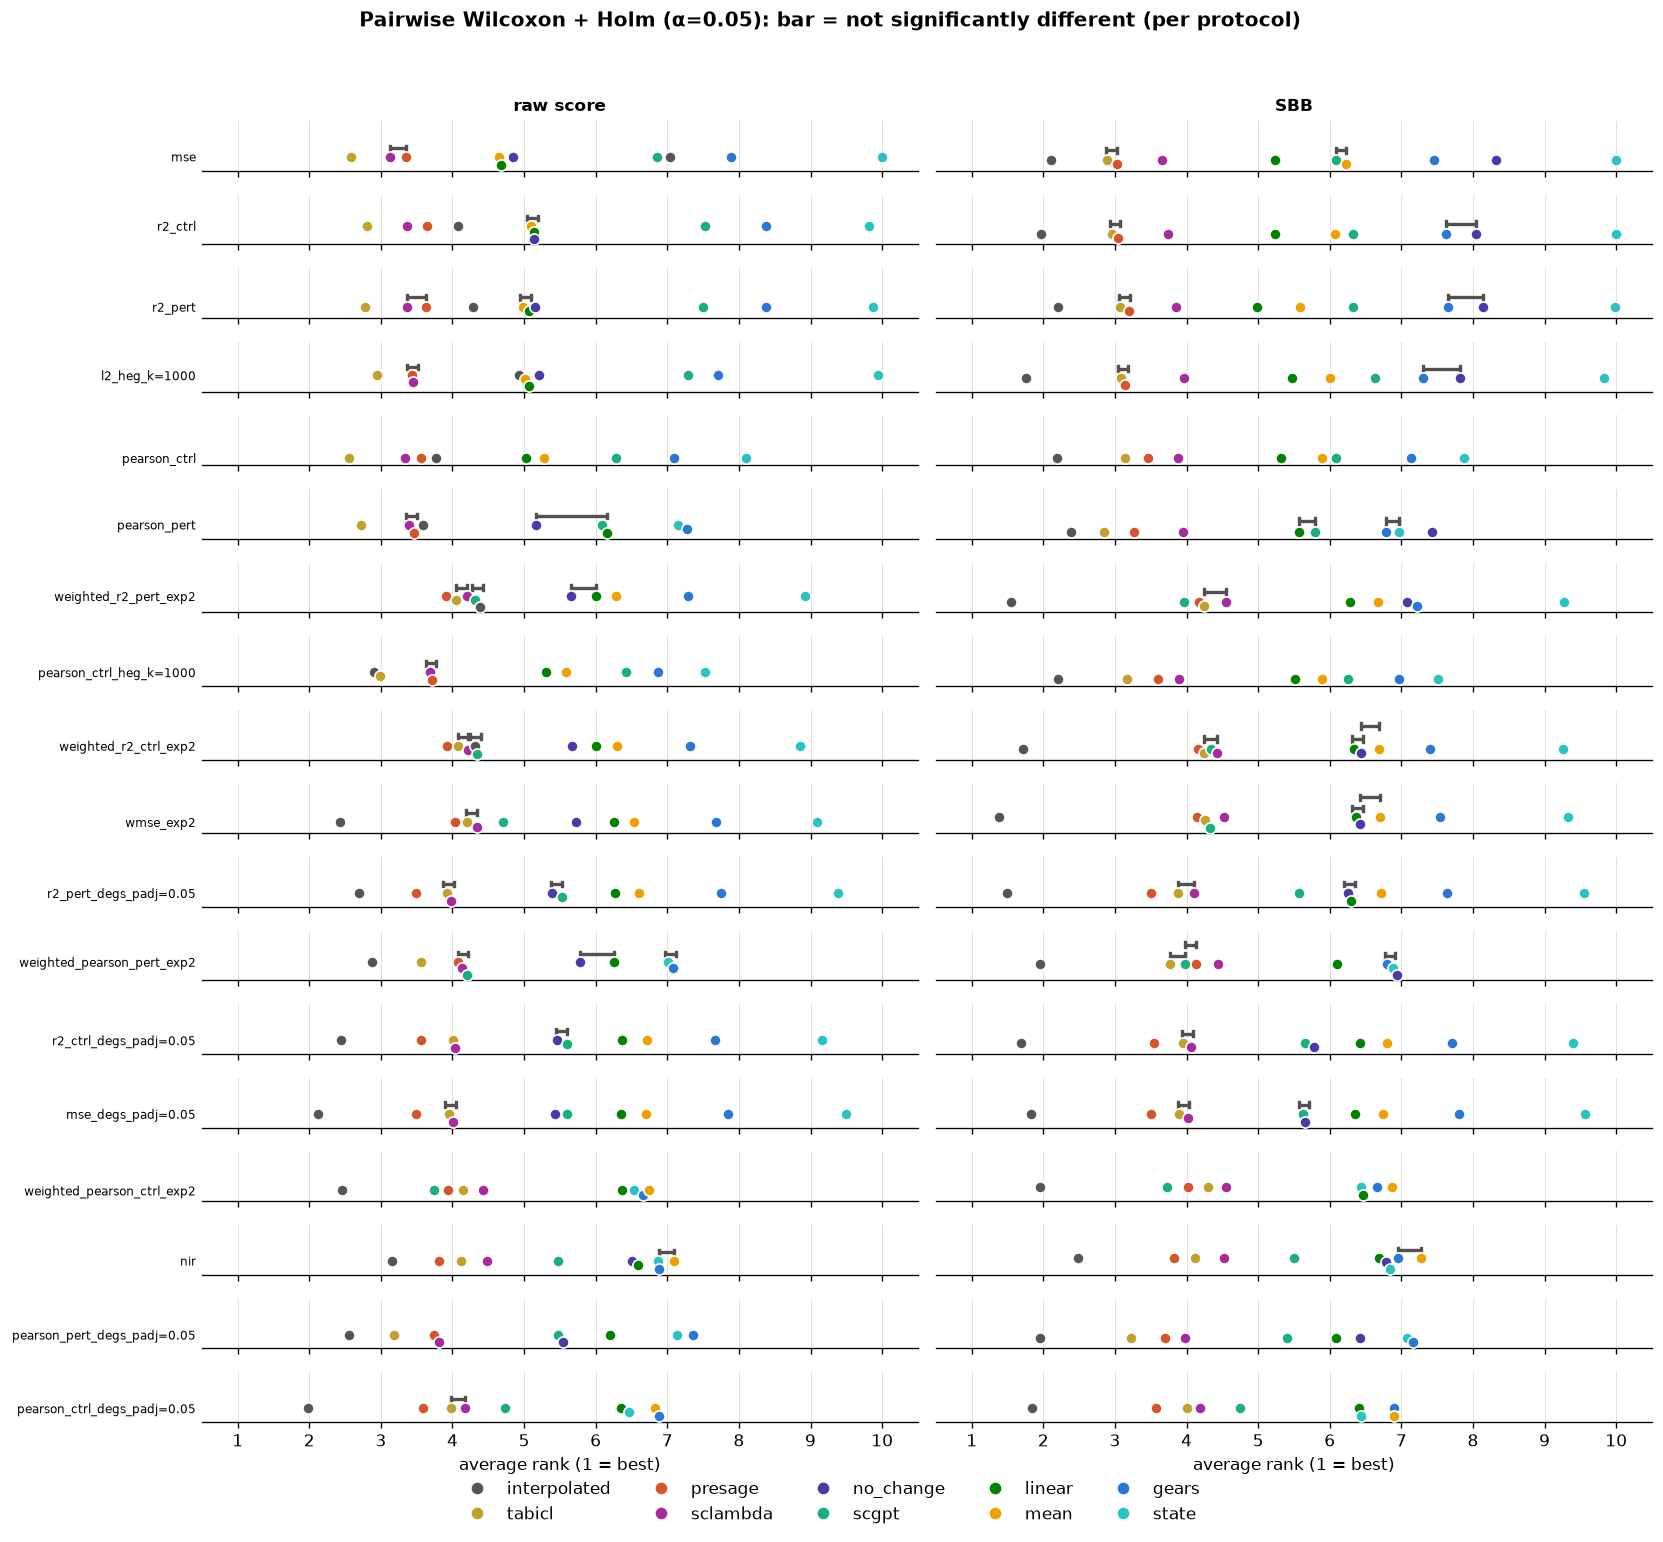

In [56]:
plot_significance_cliques(
    views_wilcoxon,
    title=f"Pairwise Wilcoxon + Holm (α={alpha:g}): bar = not significantly different (per protocol)",
)

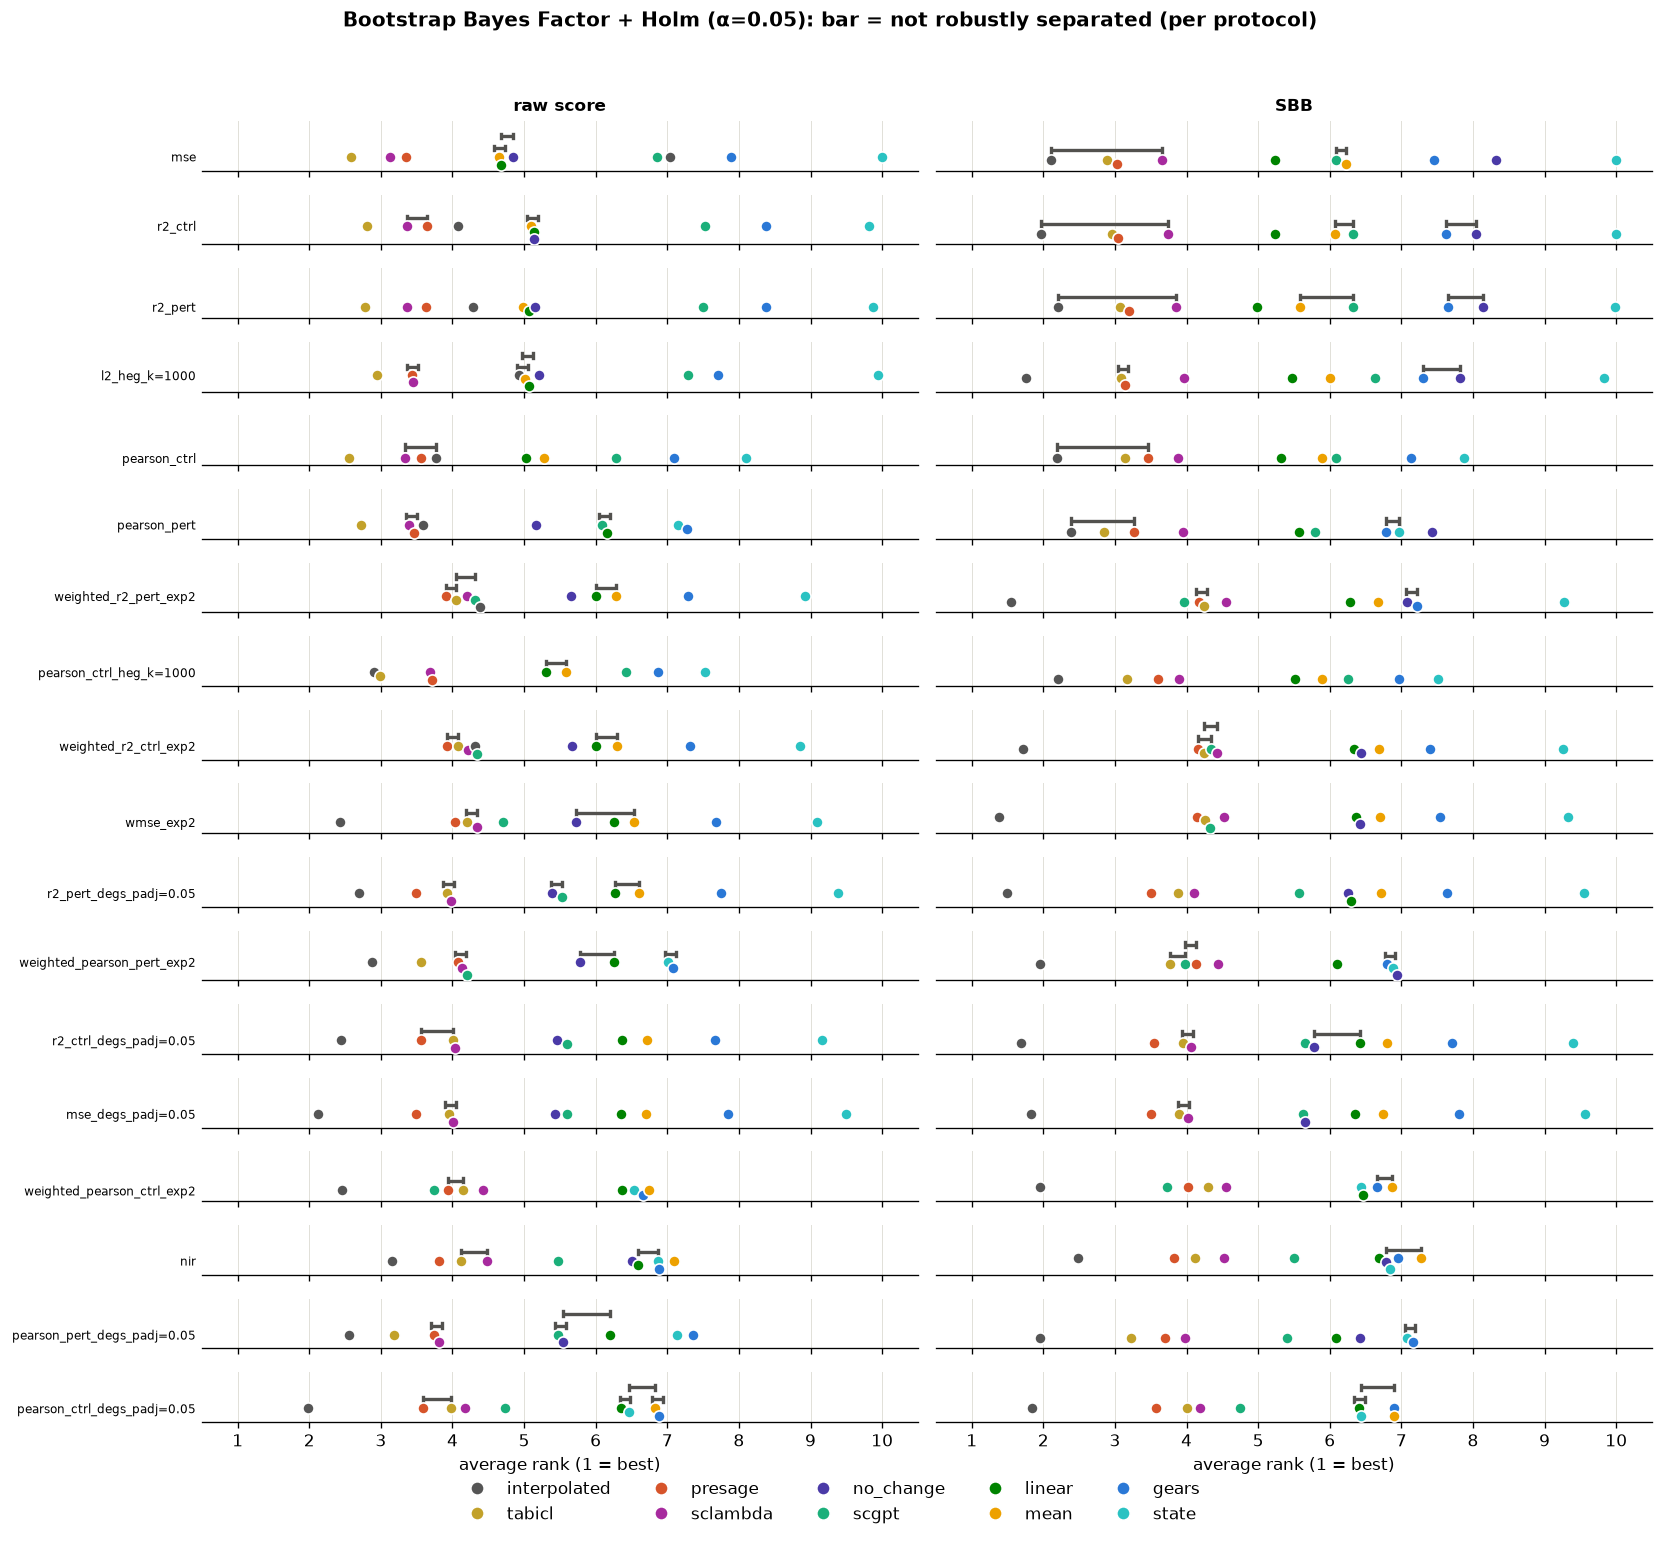

In [57]:
plot_significance_cliques(
    views_bf,
    title=f"Bootstrap Bayes Factor + Holm (α={alpha:g}): bar = not robustly separated (per protocol)",
)

**Interpretation:**

:::{dropdown} Which significance test to look at?

  Looking at significance cliques obtained either with the Wilcoxon test or with the bootstrap Bayes Factor, one can notice they marginally agree, and the cases where disagreement occurs are indeed visibly ambiguous, as shown with the stripplots of the raw score in [section 2](#2-score-predictions). Whether to keep one or the other is a matter of which question is interesting to the practitioner:

  - Wilcoxon: is the median of the per-perturbation paired difference nonzero?
  - Bayes Factor: does resampling the benchmark's own primary metric (here, each model's median score) consistently favor one model over the other?

  Both target roughly the same "is one model typically better" question, but Wilcoxon extracts it directly from the full paired-difference structure in one computation, while the bootstrap only gets one coarse win/loss draw per resample and needs many of them to build up the same picture. That makes BF the more conservative of the two: it needs a more decisive gap to reach the same conclusion Wilcoxon would, which is why most of the disagreements above run in one direction (Wilcoxon significant, BF not) rather than the other. 

  The real reason to keep both rather than picking one is that BF's *primary metric* is a free choice, not fixed to a paired difference. It can absorb any benchmark-specific notion of "better" (not just a per-perturbation median gap), closer to how {cite:t}`Dream_2019`'s own leaderboard convention was intended to work. Wilcoxon can't be generalized that way; it only ever answers the one question above.

:::

:::{dropdown} Which score to look at: raw score or the SBB one

  Both rankings overall agree even though significance cliques might differ. Model ranking is more spread out when switching from raw score to SBB, and rank switching happens mostly at less calibrated protocols. Both of these last two points are likely a result of the filtering of the perturbations that don't pass the $\text{BDS}$ threshold.

  Additionally, as already argued, SBB's calibrated score can look overly optimistic because of this filtering. Models are trained without regard to whether their loss function or evaluation protocol can actually dissociate a given perturbation from control: every perturbation is fed to the model regardless. So the SBB score is insightful for getting a sense of what's achievable on well-posed perturbations, but it isn't representative of the full range of perturbations the model actually has to handle.

  Filtering perturbations out is undesirable for a second reason: beforehand, there is no way to know whether a given perturbation will be strong enough to differ from control under a given protocol (the $\text{BDS}$ setting). A model deployed in practice doesn't get to skip the perturbations that turn out to be ambiguous, and it can't consult their outcome to decide whether to bother. 

  Then, a benchmark that only scores the well-posed subset doesn't reflect the task the model is actually being asked to solve. For these reasons, we believe the raw score is a fairer measure of the actual question at stake: how a model would perform in a deployment setting to predict truly unseen perturbations.

:::

:::{dropdown} Benchmark outcome, raw score - bayes factor view

  A few observations have already been made in earlier sections and are briefly summarized here:
  
  - `interpolated` is not the best on poorly calibrated protocols despite having *oracle* insights. It suggests such protocols shouldn't be relied on (see [section 2](#2-score-predictions)).
  - `scgpt` performing suspiciously well on weighted metrics but not on its DEG-restricted counterpart is indicative of a training shortcut of predicting very well only the gene with the strongest effect, namely the target gene (see [section 3](#3-sbb-normalization)). Notably this is also the biggest model, so the model might be over-parametrized for the task. The model completed the full range of recommended training epochs and didn't early stop, so it could probably have benefited from more training rounds (see [Models - Training diagnostics](../benchmark/models.md#training-diagnostics)).
  - {cite}`AhlmannEltze_2025`'s and {cite}`Miller_2025`'s conflicting conclusions can be reproduced based on which protocols and models are being looked at (see [section 3](#3-sbb-normalization)).

  Additionally, we can further note: 

  - `state` is performing consistently worse than other models or baselines except in *normalized inverse rank* and *pearson ctrl* weighted or DEG restricted where it doesn't end up last. This is despite `state` being one of the most recent models. A few things can be noted:
    1. `state` is the only one using a distributional loss function like MMD. This might result in predicting noisier samples and therefore to do worse on protocols that are scale-sensitive, hence explaining how it can perform better in rank-based metrics or some pearson-based protocols.
    2. `state` is trained with log fold changes, which is equivalent to centering on the control. This may explain why it performs better on `ctrl`-centered `pearson`.
    3. Interestingly, in the original paper {cite}`State_2025`, `state` is being assessed with the *normalized inverse rank*, the *DE overlap accuracy* and *Spearman effect size* (the last 2 are not reported here because the original intent of the tutorial was to reproduce {cite}`Miller_2025` and {cite}`AhlmannEltze_2025`). Also, the models benchmarked include autoencoders like $\text{scVI}$ and $\text{CPA}$, in addition to $\text{scGPT}$ present here. Even looking at the *normalized inverse rank*, `state` doesn't seem to beat `scgpt` while it seemed to manage in the original paper.

      This can be for a few one reasons: we are in a different setting than the original paper, where it was about context transfer in different cell lines rather than predicting completely unseen perturbations.

      Additionally, we minorly modified `state` to allow it to early stop, which doesn't seem to be used at all in the original implementation. Therefore, despite being fairer in regard to the other models being benchmarked, this might understate the model's actual capability, which could have benefited from a longer run. We decided to go with early stopping because the recommended amount of training steps seemed quite arbitrary, was inconsistent across the original codebase, and was surprisingly much larger than any other model's.

  - Finally, `sclambda`, `presage` and `tabiclv2` are consistently performing better than the other models. Interestingly, those models leverage information from elsewhere, namely: 
    - `presage` uses embeddings from various sources including:
      - GO, Reactome, StringDB (pathway-related) using a node2vec embedding approach
      - ESM, a protein language model to embed proteins encoded by genes
      - BioGPT, GenePT, two text-based models to embed gene summaries from NCBI
      - Cell Profiler embedding of optical pooled screening perturbation assays
      - Cancer Dependency Map
    - `tabiclv2` reuses a subset of `presage`'s embeddings:
      - Cell Profiler, GenePT, ESM, StringDB and DepMap
    - `sclambda` only uses embeddings from GenePT.

    It is interesting to see that model performance seems less a matter of architecture than it is of the appropriate gene representations, hence giving further weight to work aiming at benchmarking the actual information within each gene embedding such as {cite:t}`zhongEmbeddings_2025, hasanajEmbeddings_2025`.

    Surprisingly enough, `tabiclv2` keeps performing well, even in poorly calibrated protocols where the signal is not concentrated on any genes (either through weighting or DEG filtration). A plausible mechanism: TabICL predicts each of its PCA components independently (a separate in-context regression per component, no joint modeling across them), then reconstructs the full gene vector as a linear combination of those predictions via inverse PCA. Since each component's loading vector spans every gene, independent per-component prediction errors get mixed and partially averaged out across the whole panel at reconstruction time, rather than each gene carrying its own independent error. Hence, it smooths predictions most for genes with diffuse loadings (most non-responsive genes), which is exactly what full-panel, no-DEG-focus metrics reward.

:::

Overall, we showed how one can use `scPertEval` to benchmark models across protocols after first analyzing their respective calibration.

Additionally, we observed a failure mode where `scgpt` was only good at predicting the perturbed gene. This motivate us in a future tutorial to compare results when the perturbed gene is neither included in the training loss nor in the evaluation process. See further reading on this topic in this blog post from {cite:t}`kernfeldTargetGeneProblem_2025`.